# Figures for "An algorithm to retrieve peroxyacetyl nitrate from AIRS"

**Joshua L. Laughner$^1$, Susan S. Kulawik$^2$, Vivienne H. Payne$^1$**
1. Jet Propulsion Laboratory, California Institute of Technology, Pasadena, California, USA
2. Bay Area Environmental Research Institute/NASA Ames, Mountain View, California, USA

---

This notebook will reproduce the figures from "An algorithm to retrieve peroxyacetyl nitrate from AIRS."
Please see the README.md file in this repository for the necessary steps to set up to run this notebook.

Note that some supporting code is contained in the `src` subdirectory, specifically, the `jllutils`, `muses_utils`, and `airs_pan_ml` packages.

- `jllutils` contains general helper functions not specific to this manuscript.
- `muses_utils` contains helper functions for working with TROPESS data in general.
- `airs_pan_ml` contains the code used to train the machine learning quality filter.

If you are looking for a particular bit of code to see how something is done and it is not in the notebook itself, check those packages.

## Imports

In [10]:
import cartopy.crs as ccrs
import cartopy.feature as cfeat
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter, LatitudeLocator
import cmasher as cmr
from copy import deepcopy
from pyhdf import SD
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
from matplotlib.gridspec import GridSpec
import metpy # needed to activate accessors in xarray
from netCDF4 import Dataset
import numpy as np
import pandas as pd
from pathlib import Path
import pyhdf
from scipy.interpolate import interp1d
from scipy.stats import pearsonr
import shap
from sklearn.metrics import r2_score
from sklearn.decomposition import PCA
from tqdm import tqdm
import xarray as xr

from jllutils import miscutils
import jllutils.plots as jplt
import jllutils.geography as jgeo
import jllutils.stats as jstats
from muses_utils import quick_plots, quality, readers, images, plots, conversions

from airs_pan_ml import features, readers as aread
from airs_pan_ml.binary_flag import metrics, training
from airs_pan_ml import plots as aplt

# Leave this as False to only display the figures in the notebook.
# Set to True to save to an "img" subdirectory.
SAVE_PLOTS = False
if SAVE_PLOTS and not Path('img').exists():
    Path('img').mkdir()

## Helper functions

First we define some small helper functions we will need throughout.

In [3]:
def plot_box(west_lon, east_lon, north_lat, south_lat, ax, **style):
    x = [west_lon, east_lon, east_lon, west_lon, west_lon]
    y = [north_lat, north_lat, south_lat, south_lat, north_lat]
    style.setdefault('transform', ccrs.PlateCarree())
    ax.plot(x, y, **style)

def make_airs_filterer(*extra_filters, include_h2o=True, airs_filter='deriv'):
    filterer = quality.StdPanFilter('OSP-AIRS-v10-PAN', 'laughner', add_airs_filter=airs_filter, strat_table_dir='data/strategy_tables/')
    filterer.add_filterer(quality.VariableQualityFilterer('radianceResidualRMS', 0.5, 2))
    filterer.add_filterer(quality.VariableQualityFilterer('radianceResidualMean', -0.5, 0.5))
    if include_h2o:
        filterer.add_filterer(quality.StdFlagQualityFilterer('Quality', alternate_step='H2O-1'))
    for f in extra_filters:
        filterer.add_filterer(f)
    return filterer


def quick_plot_xpan800(ds):
    xpan800 = aread.calc_xpan800(ds)
    return xpan800, 'XPAN800 (ppb)'

## Microwindows

This section will generate Fig. 1 from the discussion paper.

In [4]:
AIRS_WINDOWS = [(772.5, 775), (780, 781.875), (793.75, 796.875), (800, 802.5), (804.375, 805)]
CRIS_WINDOWS = [(780, 783.125), (786.25, 790.625)]


def plot_microwindow_selection(fm_pantest_file, perturbation_file):
    pretty_gas = {'PAN': 'PAN', 'O3': 'O$_3$', 'CO2': 'CO$_2$', 'H2O': 'H$_2$O', 'CCL4': 'CCl$_4$'}
    ngas = len(pretty_gas)
    _, axs = plt.subplots(ngas, 1, figsize=(12, 1.4*ngas), sharex=True)

    with Dataset(fm_pantest_file) as ds:
        airs_chan_freq = ds['FREQUENCY'][0]
        airs_chan_nesr = ds['NESR'][0]
        airs_chan_freq = airs_chan_freq[airs_chan_nesr > 0]

    airs_windows = AIRS_WINDOWS
    cris_windows = CRIS_WINDOWS

    with Dataset(perturbation_file) as ds:
        freq = ds['frequency'][:].filled(np.nan)
        for ax, (gas_name, gas_label) in zip(axs, pretty_gas.items()):
            delta_bt = ds[f'{gas_name.lower()}_delta_brightness_temperature'][:].filled(np.nan)
            _plot_radiance_perturbation(freq, delta_bt, ax=ax, channels=airs_chan_freq, color='black')
            h_aw = _plot_windows(airs_windows, ax=ax, color='tab:blue', label='AIRS Windows')
            h_cw = _plot_windows(cris_windows, ax=ax, color='tab:orange', half='very-top', label='CrIS Windows')
            ax.text(0.98, 0.05, gas_label, transform=ax.transAxes, ha='right', fontsize=16)
            ax.set_xlim(770, 830)
            ax.set_xticks(np.arange(770, 831, 5)) 
            ax.set_ylabel(r'$\Delta$ BT (K)')
            ax.grid(True, axis='x')
    handles = [
        Line2D([0], [0], color='k', label='Spectrum'),
        Line2D([0], [0], marker='.', color='gray', ls='none', label='AIRS Channels'),
        h_aw,
        h_cw
    ]
    axs[0].legend(handles=handles, loc='lower center', bbox_to_anchor=(0.5, 1.01), ncol=5)
    axs[-1].set_xlabel('Frequency (cm$^{-1}$)')
        


def _plot_radiance_perturbation(freq, delta_bt, ax=None, channels=None, **style):
    ax = ax or plt.gca()
    ax.plot(freq, delta_bt, **style)
    if channels is not None:
        y = np.full(channels.size, np.nanmax(np.abs(delta_bt))*0.1)
        ax.plot(channels, y, marker='.', color='gray', ls='none')
        
        
def _plot_windows(windows, ax=None, half=None, **style):
    ax = ax or plt.gca()
    y1, y2 = ax.get_ylim()
    ax.set_ylim(y1, y2)
    if half == 'bottom':
        y2 = y1 + 0.5*(y2-y1)
    elif half == 'top':
        y1 = y1 + 0.5*(y2-y1)
    elif half == 'very-top':
        y1 = y1 + 0.8*(y2-y1)
    elif half == 'top-offset':
        y2 = y1 + 0.8*(y2-y1)
    elif half == 'bottom-offset':
        y1 = y1 + 0.2*(y2-y1)
    style.setdefault('alpha', 0.5)
    style.setdefault('color', 'tab:blue')
    for x1, x2 in windows:
        p = ax.fill_betweenx([y1,y2], x1, x2, **style)
    return p

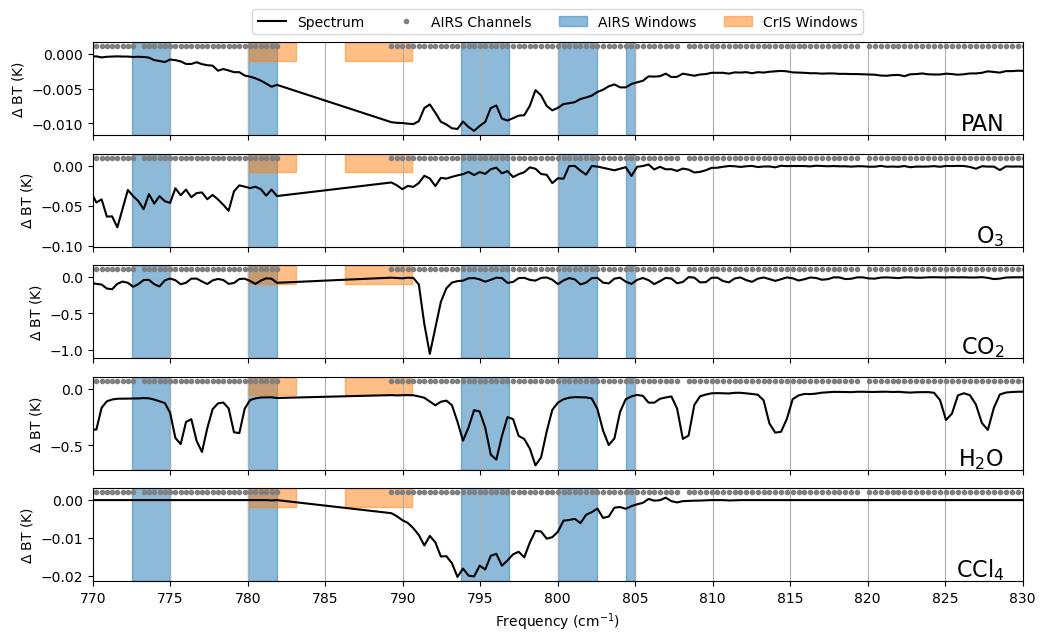

In [5]:
plot_microwindow_selection(
    fm_pantest_file='data/validation/airs-runs/airs/2020-09-11/combine/West_Coast_Fires_Pacific/Products_Radiance-FM-pantest.nc',
    perturbation_file='data/spectral-signatures.nc',
)

if SAVE_PLOTS:
    plt.savefig('img/window_selection.pdf', bbox_inches='tight')

## West Coast & Australia Fires - Cloud filtering

This section will generate Figs. 2 through 6 from the discussion paper.

In [8]:
cloud_box = [-142, -122, 30, 20]
aus_cloud_box = [171.5, 178.5, -46.5, -61.0]

### Early filter tests

First we simply plot the free tropospheric column averages of PAN from both CrIS and AIRS using simple quality filtering to show that AIRS has an expected PAN plume over the central Pacific.

In [10]:
# Define the various quality filters we use
cris_qual_filter = quality.StdFlagQualityFilterer('Quality')
basic_plus_h2o_airs_filter = make_airs_filterer(include_h2o=True, airs_filter=None)
airs_qual_filter_withpca = make_airs_filterer(quality.PCALowCloudPANFilterer(), include_h2o=False)

Reading quality flag file data/strategy_tables/OSP-AIRS-v10-PAN/QualityFlags/QualityFlag_Spec_Nadir_PAN.asc
Reading quality flag file data/strategy_tables/OSP-AIRS-v10-PAN/QualityFlags/QualityFlag_Spec_Nadir_PAN.asc


Calculating XPAN800 [######################################] 38236/38236
Calculating XPAN800 [######################################] 35934/35934
Calculating XPAN800 [######################################] 35934/35934
Loading PCA fits from cache


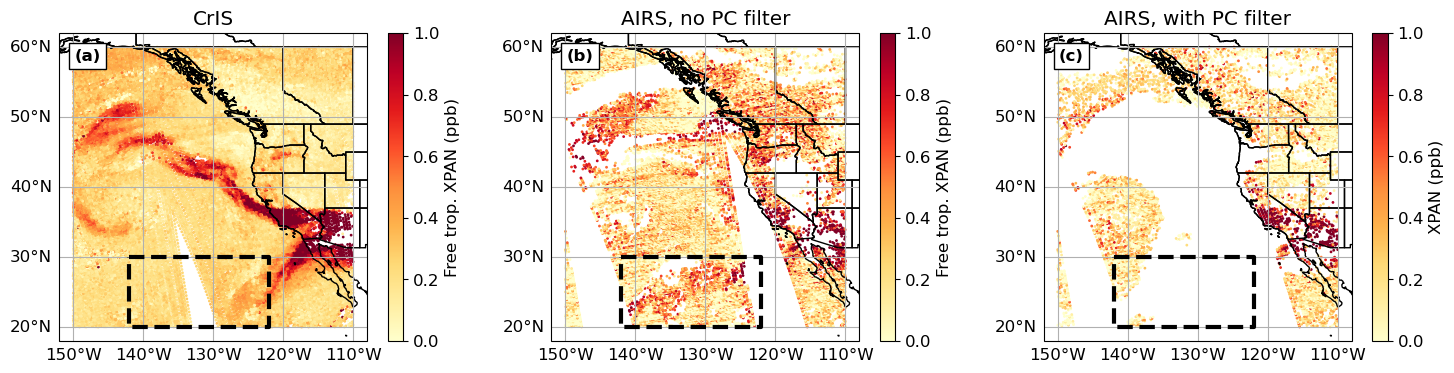

In [179]:
with plt.rc_context({'font.size': 12}):
    _, axs = plt.subplots(1,3,figsize=(18,4),subplot_kw={'projection': ccrs.PlateCarree()})

    ax = axs[0]
    quick_plots.plot_sounding_map_from_combined(
        combined_file='data/validation/airs-runs/cris/2020-09-11/combine/West_Coast_Fires_Pacific/Products_L2-PAN-0.nc',
        variable=quick_plot_xpan800,
        map_features=[cfeat.COASTLINE, cfeat.STATES],
        bias_corr=quality.CrisXpanBiasCorr(),
        filterer=cris_qual_filter,
        vmax=1,
        cblabel='Free trop. XPAN (ppb)',
        cmap='YlOrRd',
        ax=ax, s=1
    )
    plot_box(*cloud_box, ax=ax, color='k', ls='--', lw=3)
    ax.set_title('CrIS')

    ax = axs[1]
    quick_plots.plot_sounding_map_from_combined(
        'data/validation/airs-runs/airs/2020-09-11/combine/West_Coast_Fires_Pacific/Products_L2-PAN-0.nc',
        variable=quick_plot_xpan800,
        map_features=[cfeat.COASTLINE, cfeat.STATES],
        filterer=basic_plus_h2o_airs_filter,
        ax=ax,
        cblabel='Free trop. XPAN (ppb)',
        cmap='YlOrRd',
        vmax=1, s=1
    )
    plot_box(*cloud_box, ax=ax, color='k', ls='--', lw=3)
    ax.set_title('AIRS, no PC filter')

    ax = axs[2]
    quick_plots.plot_sounding_map_from_combined(
        'data/validation/airs-runs/airs/2020-09-11/combine/West_Coast_Fires_Pacific/Products_L2-PAN-0.nc',
        variable=quick_plot_xpan800,
        map_features=[cfeat.COASTLINE, cfeat.STATES],
        filterer=airs_qual_filter_withpca,
        ax=ax,
        cblabel='XPAN (ppb)',
        cmap='YlOrRd',
        vmax=1, s=1
    )

    plot_box(*cloud_box, ax=ax, color='k', ls='--', lw=3)
    ax.set_title('AIRS, with PC filter')

    for ax, label in zip(axs, 'abc'):
        ax.text(0.05, 0.95, f'({label})', transform=ax.transAxes, weight='bold', va='top', bbox={'facecolor': 'white'})

    if SAVE_PLOTS:
        plt.savefig('img/wcf-spurious-plume.png', bbox_inches='tight')
        plt.savefig('img/wcf-spurious-plume.pdf', bbox_inches='tight')

### Cloud properties

Next we plot a GOES truecolor image and MODIS-Aqua cloud fraction, cloud top pressure, and cloud top temperature to identify that the spurious PAN plume in the AIRS retrieval is correlated with low, warm clouds.
These data are included in the associated dataset for simplicity, but were originally obtained from:

- GOES: https://noaa-goes17.s3.amazonaws.com/index.html#ABI-L2-MCMIPC/2020/255/22/
- MODIS: https://ladsweb.modaps.eosdis.nasa.gov/missions-and-measurements/products/MYD06_L2/

In [4]:
def plot_wcf_modis(modis_data, vars_to_plot=None, nx=2, modis_cblabels=dict(), invert_colorbar_for=tuple(), variable_plot_kws=dict(), panel_size=(8,6), axs=None, **modis_plot_kws):
    if vars_to_plot is None:
        vars_to_plot = [k for k in modis_data if k not in {'Latitude', 'Longitude', 'Latitude_1km', 'Longitude_1km'}]
        
    nplots = len(vars_to_plot)
    if axs is None:
        sp = jplt.Subplots(nplots, nx=nx, subplot_kw={'projection': ccrs.PlateCarree()}, figsize=panel_size)
        axs = [sp.next_subplot() for _ in vars_to_plot]
    elif len(axs) != len(vars_to_plot):
        raise ValueError('Number of axes given must match the number of variables to plot')
        
    for ax, varname in zip(axs, vars_to_plot):
        xx_fills = modis_data[varname] < 0
        kws = modis_plot_kws.copy()
        kws.update(variable_plot_kws.get(varname, dict()))
        h = ax.scatter(modis_data['Longitude'][~xx_fills], modis_data['Latitude'][~xx_fills], c=modis_data[varname][~xx_fills], **kws)
        
        cblabel = modis_cblabels.get(varname, varname.replace('_', ' '))
        cb = plt.colorbar(h, ax=ax, label=cblabel)
        if varname in invert_colorbar_for:
            cb.ax.invert_yaxis()
        gl = ax.gridlines(draw_labels=True)
        gl.top_labels=False
        gl.right_labels=False

        ax.coastlines()
        ax.add_feature(cfeat.STATES)
        ax.add_feature(cfeat.LAND)
        ax.add_feature(cfeat.OCEAN)
    
    return axs
    
    
    
def load_modis_data(modis_files, datasets):
    sd_handles = [SD.SD(mf) for mf in modis_files]
    data_arrays = {n: _load_modis_sds(sd_handles, n) for n in datasets}
    return data_arrays


def load_modis_coords(myd06_files, infer_1km=True):
    def find_myd03(f6):
        f6 = Path(f6)
        # Assume MYD06 file = MYD06_L2.A2004200.1555.061.2018015111612.hdf
        # and MYD03 file = MYD03.A2004200.1555.061.2018014232916.hdf
        # so get the 2nd, 3rd, and 4th parts (separated by '.')
        date, time, vers = f6.name.split('.')[1:4]
        f3pattern = f'MYD03.{date}.{time}.{vers}.*.hdf'
        f3 = list(f6.parent.glob(f3pattern))
        if len(f3) == 1:
            return str(f3[0])
        else:
            raise IOError(f'Could not find MYD03 file matching {f3pattern} in {f6.parent}')
            
    latlon = load_modis_data(myd06_files, ['Latitude', 'Longitude'])
    if infer_1km:
        myd03_files = [find_myd03(f) for f in myd06_files]
        latlon_1km = {f'{k}_1km': v for k, v in load_modis_data(myd03_files, ['Latitude', 'Longitude']).items()}
        latlon.update(latlon_1km)
        
    return latlon
    
    
def _load_modis_sds(handles, dset_name):
    all_data = []
    for h in handles:
        sds = h.select(dset_name)
        data = sds[:]
        if hasattr(sds, 'add_offset'):
            data = data - sds.add_offset
        if hasattr(sds, 'scale_factor'):
            data = data * sds.scale_factor
        
        if np.issubdtype(data.dtype, np.floating):
            data = np.ma.masked_where(np.isclose(data, sds._FillValue), data)
        else:
            data = np.ma.masked_where(data == sds._FillValue, data)
            
        all_data.append(data)
        
    all_data = np.ma.concatenate(all_data, axis=0)

    return all_data

In [13]:
goes_wcf_file = 'data/goes-abi/OR_ABI-L2-MCMIPC-M6_G17_s20202552211176_e20202552213561_c20202552214089.nc'
wcf_img = images.GoesImageProvider.from_abi_file(goes_wcf_file)
cris_clear_goes_wcf_file = 'data/goes-abi/OR_ABI-L2-MCMIPC-M6_G17_s20202552111176_e20202552113560_c20202552114084.nc'
cris_clear_goes_wcf_img = images.GoesImageProvider.from_abi_file(cris_clear_goes_wcf_file)
cris_cloudy_goes_wcf_file = 'data/goes-abi/OR_ABI-L2-MCMIPC-M6_G17_s20202552246176_e20202552248560_c20202552249084.nc'
cris_cloudy_goes_wcf_img = images.GoesImageProvider.from_abi_file(cris_cloudy_goes_wcf_file)

In [14]:
wcf_files = ['data/modis-clouds/MYD06_L2.A2020255.2210.061.2020258150535.hdf', 'data/modis-clouds/MYD06_L2.A2020255.2215.061.2020258150531.hdf']
wcf_modis = load_modis_coords(wcf_files)
tmp = load_modis_data(wcf_files, ['Cloud_Fraction', 'Cloud_Top_Pressure', 'Cloud_Top_Temperature'])
wcf_modis.update(tmp)

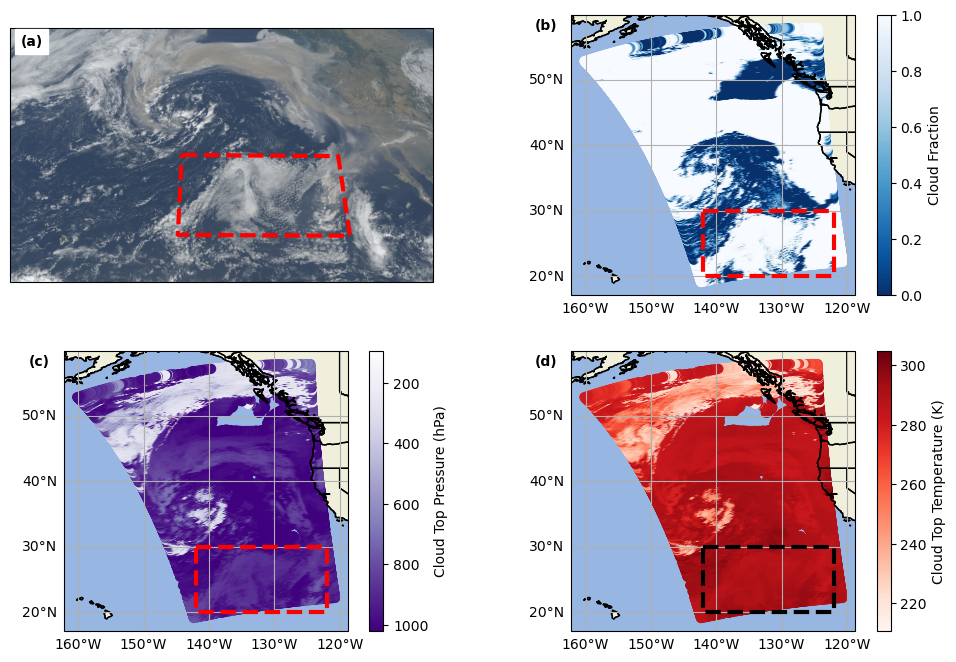

In [15]:
fig = plt.figure(figsize=(12,8))
ax = fig.add_subplot(2, 2, 1 ,projection=wcf_img._proj)
wcf_img.add_image(ax)
plot_box(*cloud_box, ax=ax, color='r', ls='--', lw=3)
ax.text(0.025, 0.975, '(a)', va='top', transform=ax.transAxes, fontweight='bold', backgroundcolor='white')

modis_axs = [fig.add_subplot(2, 2, i, projection=ccrs.PlateCarree()) for i in range(2,5)]
plot_wcf_modis(
    wcf_modis,
    modis_cblabels={'Cloud_Top_Pressure': 'Cloud Top Pressure (hPa)', 'Cloud_Top_Temperature': 'Cloud Top Temperature (K)', 'Cloud_Fraction': 'Cloud Fraction'},
    invert_colorbar_for=['Cloud_Top_Pressure'],
    variable_plot_kws={'Cloud_Top_Pressure': {'cmap': 'Purples'}, 'Cloud_Top_Temperature': {'cmap': 'Reds'}, 'Cloud_Fraction': {'cmap': 'Blues_r', 'vmin': 0, 'vmax': 1.0}},
    axs=modis_axs
)

for ax in modis_axs[:-1]:
    plot_box(*cloud_box, ax, ls='--', lw=3, color='red')
plot_box(*cloud_box, modis_axs[-1], ls='--', lw=3, color='k')

jplt.label_subplots(modis_axs, seq='bcd', xpos=-0.05)
if SAVE_PLOTS:
    plt.savefig('img/wcf-cloud-properties.png', bbox_inches='tight')
    plt.savefig('img/wcf-cloud-properties.pdf', bbox_inches='tight')

### EOF method

Here, we decompose the AIRS radiances over the northern Pacific on 2020-09-11 into EOFs and plot both the first three EOFs and the spatial distribution of the first two EOFs' principle components.

In [4]:
def fit_pca_for_plots(wcf_file='data/validation/airs-runs/airs/2020-09-11/combine/West_Coast_Fires_Pacific/Products_Radiance-FM-pantest.nc'):
    with Dataset(wcf_file) as ds:
        data = dict(
            lon=readers.get_nc_var(ds, 'LONGITUDE'),
            lat=readers.get_nc_var(ds, 'LATITUDE'),
            freq=readers.get_nc_var(ds, 'FREQUENCY')[0],
            rad=readers.get_nc_var(ds, 'RADIANCEOBSERVED')
        )
        data['rad'] = conversions.bt(data['freq'], data['rad'])
        data = _clean_rad_data(data)
        
    pca = PCA()
    data['transform'] = pca.fit_transform(data['rad'])
    data['pca'] = pca
    return data


def plot_pca_coefficients(pca_data, component_inds=(0,1,2), axs=None):
    if axs is None:
        nx = len(component_inds)
        _, axs = plt.subplots(1, nx, figsize=(6*nx, 4), subplot_kw={'projection': ccrs.PlateCarree()})
        if nx == 1:
            axs = [axs]
        
    for ind, ax in zip(component_inds, axs):
        h = ax.scatter(pca_data['lon'], pca_data['lat'], c=pca_data['transform'][:,ind], cmap='nipy_spectral')
        plt.colorbar(h, ax=ax, label=f'PCA coeff #{ind+1}')
        ax.add_feature(cfeat.STATES, linewidth=0.5)
        ax.coastlines()
        gl = ax.gridlines(draw_labels=True)
        gl.top_labels = False
        gl.right_labels = False

    return axs


def _clean_rad_data(rad_data):
    """Clean up data for PCA
    
    Removes spectra that contain NaNs and frequencies that contain near-0 values.
    Returns a dictionary with the same structure as the input, but with the data
    cut down in this way.
    """
    xx = ~np.any(np.isnan(rad_data['rad']), axis=1)
    yy = ~np.any(rad_data['rad'][xx] < 1, axis=0)
    rad_data_clean = {k: v[xx] for k, v in rad_data.items() if k != 'freq'}
    rad_data_clean['freq'] = rad_data['freq'][yy]
    rad_data_clean['rad'] = rad_data_clean['rad'][:,yy]
    return rad_data_clean

In [8]:
def plot_pca_components(pca_info, component_inds=(0,1,2), ax=None, **style):
    ax = ax or plt.gca()
    if isinstance(pca_info, dict):
        freq = pca_info['freq']
        components = pca_info['pca'].components_
        frac_var = pca_info['pca'].explained_variance_ratio_ * 100
    else:
        with Dataset(pca_info) as ds:
            freq = ds['frequency'][:]
            components = ds['components'][:]
            frac_var = ds['explained_variance_ratio'][:] * 100
        
    for i in component_inds:
        norm = np.nanmax(np.abs(components[i]))
        style.setdefault('label', f'EOF #{i+1}, EV = {frac_var[i]:.2f}%')
        ax.plot(freq, components[i] / norm, **style)
    ax.legend()
    ax.set_xlabel('Frequency (cm$^{-1}$)')
    ax.set_ylabel('Normalize brightness temperature')
    ax.grid(True)
    
    
def plot_pca_components_sep_axes(pca_info, component_inds=(0,1,2), legend_loc=None, spectral_signature_file='data/spectral-signatures.nc'):
    cm = plt.get_cmap('tab10')
    ny = len(component_inds)
    if spectral_signature_file is not None:
        _, all_axs = plt.subplots(ny+1, 1, figsize=(12, 2*(ny+1)), sharex=True, sharey=True)
        axs = all_axs[1:]
    else:
        _, axs = plt.subplots(ny, 1, figsize=(12, 2*ny), sharex=True, sharey=True)
        
    for col_ind, (comp_ind, ax) in enumerate(zip(component_inds, axs)):
        color = cm(col_ind)
        plot_pca_components(pca_info, component_inds=[comp_ind], ax=ax, color=color)
        if col_ind != ny // 2:
            ax.set_ylabel('')
        if col_ind != ny - 1:
            ax.set_xlabel('')
        if legend_loc:
            ax.legend(loc=legend_loc)

    if spectral_signature_file is not None:
        with Dataset(spectral_signature_file) as ds:
            freq = ds['frequency'][:].filled(np.nan)
            pan_bt = ds['pan_delta_brightness_temperature'][:].filled(np.nan)
            h2o_bt = ds['h2o_delta_brightness_temperature'][:].filled(np.nan)
        ax = all_axs[0]
        _, _, ax2 = jplt.create_twin_axes_with_color(color2='gray', ax=ax)
        ax2.plot(freq, pan_bt, color='gray')
        ax.plot(freq, h2o_bt, color='black')
        handles = [
            Line2D([0], [0], color='gray', label='PAN'),
            Line2D([0], [0], color='black', label='H$_2$O'),
        ]
        ax.legend(handles=handles, loc='lower right', ncol=2)
        ax.grid(True)
        ax.set_ylabel('H$_2$O spectral sig. (K)')
        ax2.set_ylabel('PAN spectral sig. (K)')

In [6]:
wcf_pca_data = fit_pca_for_plots()

/Users/laughner/Documents/My Papers/AIRS PAN Paper/notebook-repo/src/muses_utils/muses_utils/conversions.py:47: RuntimeWarning: divide by zero encountered in true_divide
  bt = RADCN2 * frequency / np.log(1 + (RADCN1 * frequency**3 / rad))


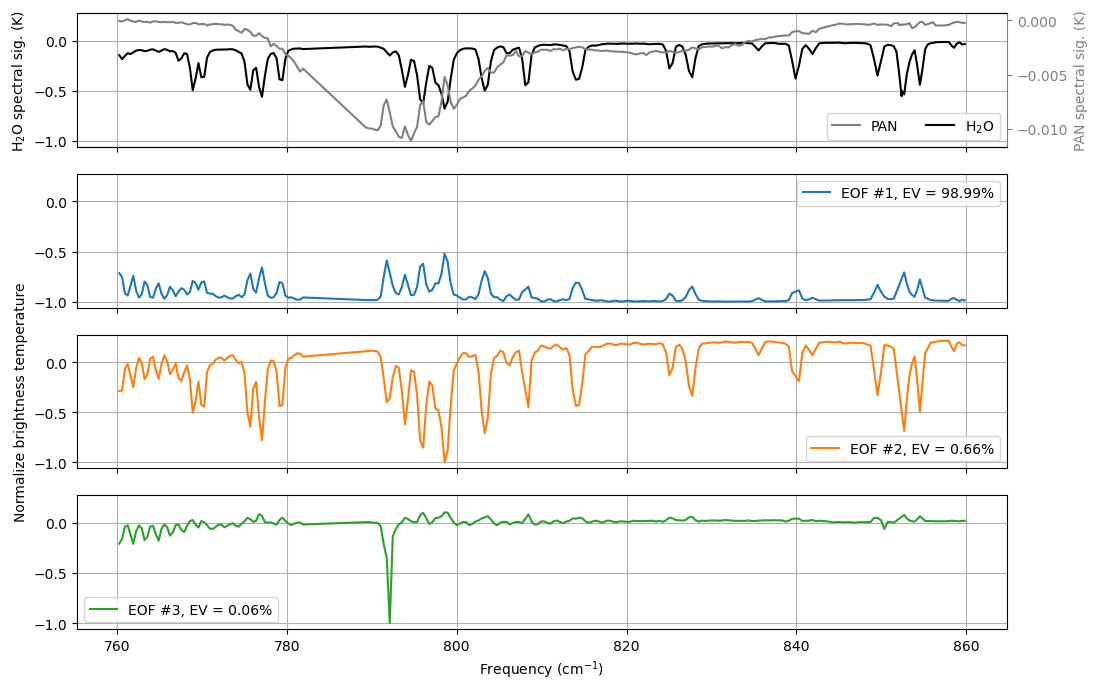

In [9]:
plot_pca_components_sep_axes(wcf_pca_data)
if SAVE_PLOTS:
    plt.savefig('img/wcf-radiance-eofs.pdf', bbox_inches='tight')

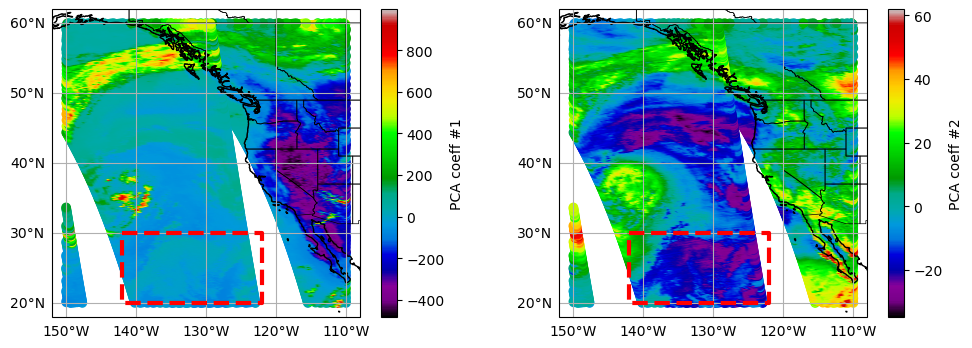

In [29]:
axs = plot_pca_coefficients(wcf_pca_data, component_inds=(0,1))
for ax in axs:
    plot_box(*cloud_box, ax, ls='--', lw=3, color='r')
if SAVE_PLOTS:
    plt.savefig('img/wcf-rad-pcs.png', bbox_inches='tight')
    plt.savefig('img/wcf-rad-pcs.pdf', bbox_inches='tight')

The next few cells repeat the check for cloud-influenced errors in the plume from the 2019/2020 Australian Bush Fires.

In [5]:
aus_modis_files = sorted(p.as_posix() for p in Path('data/modis-clouds/').glob('MYD??_L2.A2020001*.hdf'))
aus_modis_data = load_modis_data(aus_modis_files, ['Longitude', 'Latitude', 'Cloud_Fraction', 'Cloud_Top_Pressure', 'Cloud_Top_Temperature'])
aus_modis_data['Cloud_Top_Pressure'] = np.ma.masked_less(aus_modis_data['Cloud_Top_Pressure'], 0)
aus_modis_data['Cloud_Top_Temperature'] = np.ma.masked_less(aus_modis_data['Cloud_Top_Temperature'], 0)

Calculating XPAN800 [######################################] 51314/51314
Calculating XPAN800 [######################################] 50966/50966
Calculating XPAN800 [######################################] 50966/50966
Loading PCA fits from cache


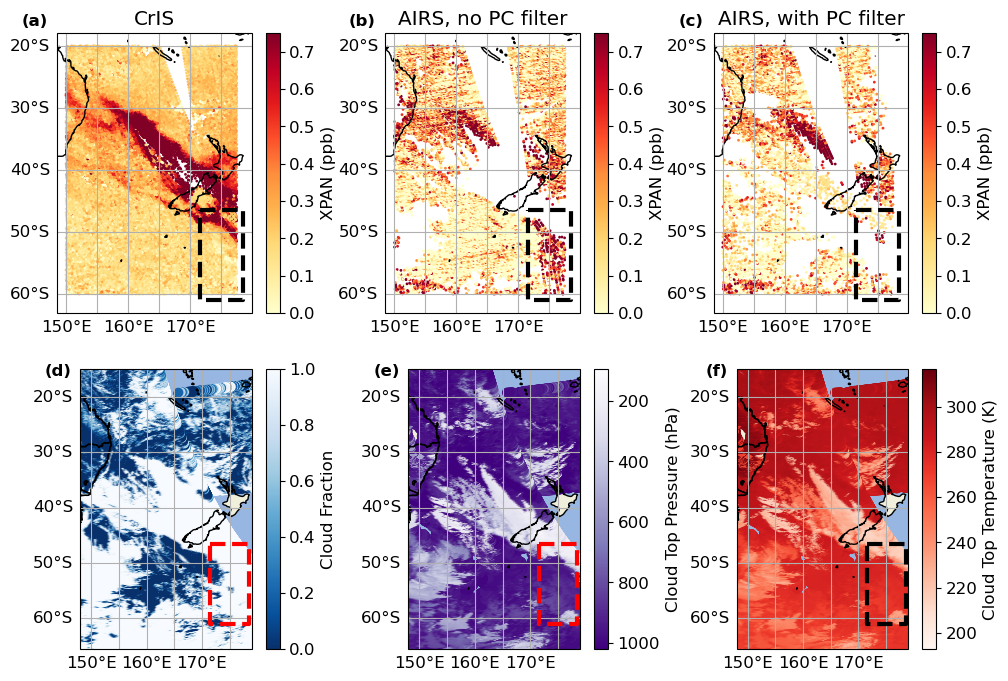

In [11]:
with plt.rc_context({'font.size': 12}):
    _, axs = plt.subplots(2, 3, figsize=(12,8), subplot_kw={'projection': ccrs.PlateCarree()})
    
    ax = axs[0,0]
    cris_qual_filter = quality.StdFlagQualityFilterer('Quality')
    quick_plots.plot_sounding_map_from_combined(
        combined_file='data/validation/airs-runs/cris/2020-01-01/combine/Australian_Fires_PAN/Products_L2-PAN-0.nc',
        variable=quick_plot_xpan800,
        map_features=[cfeat.COASTLINE],
        bias_corr=quality.CrisXpanBiasCorr(),
        filterer=cris_qual_filter,
        vmax=0.75, s=1,
        cblabel='XPAN (ppb)',
        cmap='YlOrRd',
        ax=ax
    )
    plot_box(*aus_cloud_box, ax=ax, color='k', ls='--', lw=3)
    ax.set_title('CrIS')

    ax = axs[0,1]
    quick_plots.plot_sounding_map_from_combined(
        'data/validation/airs-runs/airs/2020-01-01/combine/Australian_Fires_PAN/Products_L2-PAN-0.nc',
        variable=quick_plot_xpan800,
        map_features=[cfeat.COASTLINE],
        filterer=basic_plus_h2o_airs_filter,
        ax=ax,
        cblabel='XPAN (ppb)',
        cmap='YlOrRd',
        vmax=0.75, s=1
    )
    plot_box(*aus_cloud_box, ax=ax, color='k', ls='--', lw=3)
    ax.set_title('AIRS, no PC filter')

    ax = axs[0,2]
    quick_plots.plot_sounding_map_from_combined(
        'data/validation/airs-runs/airs/2020-01-01/combine/Australian_Fires_PAN/Products_L2-PAN-0.nc',
        variable=quick_plot_xpan800,
        map_features=[cfeat.COASTLINE],
        filterer=airs_qual_filter_withpca,
        ax=ax,
        cblabel='XPAN (ppb)',
        cmap='YlOrRd',
        vmax=0.75, s=1
    )
    plot_box(*aus_cloud_box, ax=ax, color='k', ls='--', lw=3)
    ax.set_title('AIRS, with PC filter')

    plot_wcf_modis(
        aus_modis_data,
        modis_cblabels={'Cloud_Top_Pressure': 'Cloud Top Pressure (hPa)', 'Cloud_Top_Temperature': 'Cloud Top Temperature (K)', 'Cloud_Fraction': 'Cloud Fraction'},
        invert_colorbar_for=['Cloud_Top_Pressure'],
        variable_plot_kws={'Cloud_Top_Pressure': {'cmap': 'Purples'}, 'Cloud_Top_Temperature': {'cmap': 'Reds'}, 'Cloud_Fraction': {'cmap': 'Blues_r', 'vmin': 0, 'vmax': 1.0}},
        axs=axs[1]
    )
    
    for iax, ax in enumerate(axs[1]):
        ax.set_extent([148, 179, -65, -15])
        color = 'k' if iax == 2 else 'r'
        plot_box(*aus_cloud_box, ax=ax, lw=3, color=color, ls='--')

    jplt.label_subplots(axs[0], seq='abc', ypos=1.025, xpos=-0.05)
    jplt.label_subplots(axs[1], seq='def', ypos=0.975, xpos=-0.05)
    if SAVE_PLOTS:
        plt.savefig('img/pca-filter-results.png', bbox_inches='tight')
        plt.savefig('img/pca-filter-results.pdf', bbox_inches='tight')
    

Next we repeat this check once more over the Amazon, to show that this issue does not seem to occur over land.

In [25]:
amazon_modis_files = sorted(p.as_posix() for p in Path('data/modis-clouds/amazon/').glob('MYD??_L2.A2020255*.hdf'))
amazon_modis_data = load_modis_data(amazon_modis_files, ['Longitude', 'Latitude', 'Cloud_Fraction', 'Cloud_Top_Pressure', 'Cloud_Top_Temperature'])
amazon_modis_data['Cloud_Top_Pressure'] = np.ma.masked_less(amazon_modis_data['Cloud_Top_Pressure'], 0)
amazon_modis_data['Cloud_Top_Temperature'] = np.ma.masked_less(amazon_modis_data['Cloud_Top_Temperature'], 0)

In [26]:
amazon_cloud_poly = [
    (-70, -10),
    (-57, -10),
    (-60, 10),
    (-75, 10),
    (-70, -10)
]
amazon_cloud_poly_x = [c[0] for c in amazon_cloud_poly]
amazon_cloud_poly_y = [c[1] for c in amazon_cloud_poly]

Calculating XPAN800 [######################################] 27753/27753
Calculating XPAN800 [######################################] 34864/34864


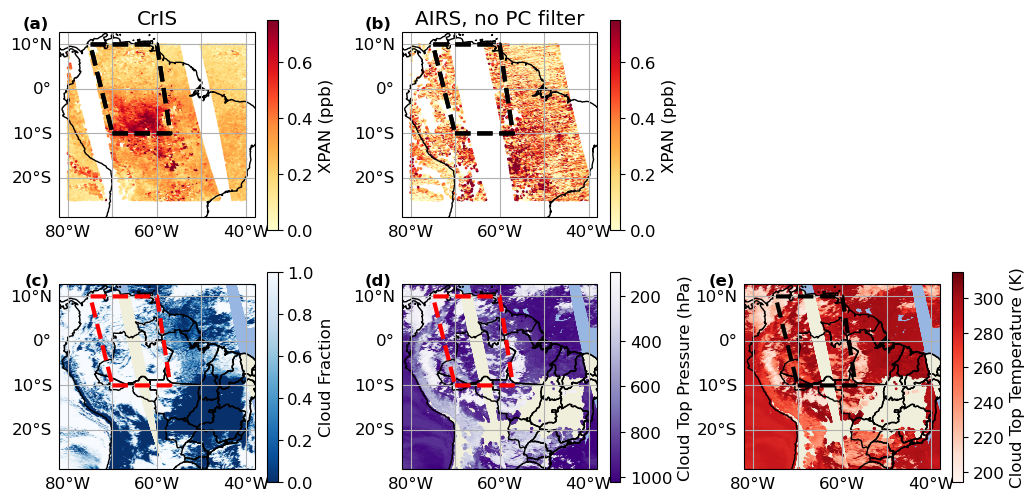

In [181]:
with plt.rc_context({'font.size': 12}):
    _, axs = plt.subplots(2, 3, figsize=(12,6), subplot_kw={'projection': ccrs.PlateCarree()}, gridspec_kw={'wspace': 0.4})

    axs[0,2].axis('off')
    
    ax = axs[0,0]
    cris_qual_filter = quality.StdFlagQualityFilterer('Quality')
    quick_plots.plot_sounding_map_from_combined(
        combined_file='data/validation/airs-runs/cris/2020-09-11/combine/Amazon_Fires_PAN/Products_L2-PAN-0.nc',
        variable=quick_plot_xpan800,
        map_features=[cfeat.COASTLINE],
        bias_corr=quality.CrisXpanBiasCorr(),
        filterer=cris_qual_filter,
        vmax=0.75, s=1,
        cblabel='XPAN (ppb)',
        cmap='YlOrRd',
        ax=ax
    )
    ax.plot(amazon_cloud_poly_x, amazon_cloud_poly_y, color='k', ls='--', lw=3)
    ax.set_title('CrIS')

    ax = axs[0,1]
    quick_plots.plot_sounding_map_from_combined(
        'data/validation/airs-runs/airs/2020-09-11/combine/Amazon_Fires_PAN/Products_L2-PAN-0.nc',
        variable=quick_plot_xpan800,
        map_features=[cfeat.COASTLINE],
        filterer=basic_plus_h2o_airs_filter,
        ax=ax,
        cblabel='XPAN (ppb)',
        cmap='YlOrRd',
        vmax=0.75, s=1
    )

    ax.plot(amazon_cloud_poly_x, amazon_cloud_poly_y, color='k', ls='--', lw=3)
    ax.set_title('AIRS, no PC filter')

    plot_wcf_modis(
        amazon_modis_data,
        modis_cblabels={'Cloud_Top_Pressure': 'Cloud Top Pressure (hPa)', 'Cloud_Top_Temperature': 'Cloud Top Temperature (K)', 'Cloud_Fraction': 'Cloud Fraction'},
        invert_colorbar_for=['Cloud_Top_Pressure'],
        variable_plot_kws={'Cloud_Top_Pressure': {'cmap': 'Purples'}, 'Cloud_Top_Temperature': {'cmap': 'Reds'}, 'Cloud_Fraction': {'cmap': 'Blues_r', 'vmin': 0, 'vmax': 1.0}},
        s=1, axs=axs[1]
    )

    for ax in axs[0,:2]:
        ax.set_extent([-82, -38, -27, 12])
        ax.plot(amazon_cloud_poly_x, amazon_cloud_poly_y, color='k', ls='--', lw=3)
    for iax, ax in enumerate(axs[1]):
        ax.set_extent([-82, -38, -27, 12])
        color = 'k' if iax == 2 else 'r'
        ax.plot(amazon_cloud_poly_x, amazon_cloud_poly_y, color=color, ls='--', lw=3)

    jplt.label_subplots(axs[0,:2], seq='ab', ypos=1.025, xpos=-0.05)
    jplt.label_subplots(axs[1], seq='cde', ypos=0.995, xpos=-0.05)
    if SAVE_PLOTS:
        plt.savefig('img/amazon-xpan-and-modis-cloud.png', bbox_inches='tight')
        plt.savefig('img/amazon-xpan-and-modis-cloud.pdf', bbox_inches='tight')
    

## Machine learning filter

This section deals with training the machine learning (decision tree) quality filter. 

### Utilities

Here, we define some labels for the plots and some helper functions to add the inputs for the decision tree to dataframes with the AIRS and CrIS retrieval data.

In [12]:
CRIS_LABELS = {
    'c_hat_pwak_bc': 'CrIS XPAN800 (ppb, H$_2$O BC + AIRS AKs)',
    'c_hat_pwak': 'CrIS XPAN800 (ppb, AIRS AK correction)',
    'xpan_cris': 'CrIS XPAN800 (ppb, no correction)'
}

VAL_CASE_LABELS = {
    'afr-sep11': 'Africa (2020-09-11)',
    'ama-sep11': 'Amazon (2020-09-11)',
    'aus-jan05': 'Australia/NZ (2020-01-05)',
    'wcf-sep11': 'US West Coast (2020-09-11)'
}

In [13]:
from dataclasses import dataclass
from typing import Dict

@dataclass
class ModelEval:
    land_model: training.tree.DecisionTreeClassifier
    ocean_model: training.tree.DecisionTreeClassifier
    features: features.FeatureSet
    flagger: training.TrainingFlag

    @classmethod
    def train_model(cls, training_data: pd.DataFrame, features: features.FeatureSet, flagger: training.TrainingFlag, split_land_ocean: bool):
        # Only use data that passed the PC-based filter, we don't
        # want to mess with the cloud-influenced soundings
        is_good = training_data.pca_filter
        if split_land_ocean:
            is_land = training_data.is_land
            land_model = training.make_model(training_data.loc[is_good & is_land, :], input_features=features, flagger=flagger)
            ocean_model = training.make_model(training_data.loc[is_good & ~is_land, :], input_features=features, flagger=flagger)
        else:
            land_model = training.make_model(training_data.loc[is_good, :], input_features=features, flagger=flagger)
            ocean_model = land_model

        return cls(land_model=land_model, ocean_model=ocean_model, features=features, flagger=flagger)

    def predict(self, val_data: pd.DataFrame):
        is_land = val_data.is_land
        is_good = np.zeros(val_data.shape[0], dtype=bool)
        is_not_na = ~val_data.isna().any(axis=1).to_numpy()
        is_good[is_land & is_not_na] = training.model_prediction(
            model=self.land_model,
            val_df_full=val_data.loc[is_land & is_not_na, :],
            features=self.features
        )
        is_good[~is_land & is_not_na] = training.model_prediction(
            model=self.ocean_model,
            val_df_full=val_data.loc[~is_land & is_not_na, :],
            features=self.features
        )
        return is_good


def load_xpan_df_for_ml(keys):
    pca_filter = quality.PCALowCloudPANFilterer()
    test_dirs = aread.test_cases_by_key('airs')
    df = aread.load_xpan_dataframe(keys, apply_cris_h2o_filter=False, land_only=False)

    extra_dfs = []
    for test_key in keys:
        l2_file = test_dirs[test_key] / 'Products_L2-PAN-0.nc'
        with Dataset(l2_file) as ds:
            sids = aread._convert_sounding_ids(aread._get_nc_var(ds, 'SoundingID'))
            is_land = (aread._get_nc_var(ds, 'LandFlag') == 1)
            pca_ok = pca_filter.quality_flags(l2_file)
            extra_dfs.append(pd.DataFrame({'pca_ok': pca_ok, 'is_land': is_land, 'pca_filter': is_land | pca_ok}, index=sids))

    extra_dfs = pd.concat(extra_dfs)
    df =  pd.merge(df, extra_dfs, left_index=True, right_index=True)
    return add_ml_vars(df)
    

def add_ml_vars(df, combine_dir=None):
    if combine_dir is not None:
        keys = aread._get_test_keys_from_df(df)
        assert len(keys) == 1
        combine_dir = {keys[0]: Path(combine_dir)}
    df = aread.load_and_merge_quality_vars(df, airs_combine_dirs=combine_dir)
    return aread.load_and_merge_radiance_vars(df, airs_combine_dirs=combine_dir)

This next cell loads the retrieval output from the associated dataset, but does not add in the decision tree inputs yet.
As shown in Table 3 of the paper, we use data from the Australian Bush Fires on 2020-01-01 and US West Coast Fires on 2020-09-13 as training data, with four other region/day combinations as testing data.
These function will apply the averaging kernel correction and H2O bias correction to the data.

In [14]:
training_df_full = load_xpan_df_for_ml(['aus-jan01', 'wcf-sep13'])

Loading aus-jan01
Calculating XPAN800 [######################################] 50966/50966
Calculating XPAN800 [######################################] 51314/51314
NOT Including H2O-1 quality flag in CrIS filtering
CrIS has 51314 soundings before quality filtering, 49731 after
Matching AIRS to nearest CrIS [############################] 50966/50966
Calculating c_hat values [#################################] 50966/50966

Loading wcf-sep13
Calculating XPAN800 [######################################] 34076/34076
Calculating XPAN800 [######################################] 37636/37636
NOT Including H2O-1 quality flag in CrIS filtering
CrIS has 37636 soundings before quality filtering, 36786 after
Matching AIRS to nearest CrIS [############################] 34076/34076
Calculating c_hat values [#################################] 34076/34076

Loading PCA fits from cache
Loading PCA fits from cache


/Users/laughner/Documents/My Papers/AIRS PAN Paper/notebook-repo/src/airs-pan-ml/airs_pan_ml/readers.py:699: RuntimeWarning: divide by zero encountered in true_divide
  bt = RADCN2 * frequency / np.log(1 + (RADCN1 * frequency**3 / rad))


In [15]:
aus_val_df_full = load_xpan_df_for_ml(['aus-jan05'])
wcf_val_df_full = load_xpan_df_for_ml(['wcf-sep11'])
ama_val_df_full = load_xpan_df_for_ml(['ama-sep11'])
afr_val_df_full = load_xpan_df_for_ml(['afr-sep11'])

Loading aus-jan05
Calculating XPAN800 [######################################] 48559/48559
Calculating XPAN800 [######################################] 52279/52279
NOT Including H2O-1 quality flag in CrIS filtering
CrIS has 52279 soundings before quality filtering, 50389 after
Matching AIRS to nearest CrIS [############################] 48559/48559
Calculating c_hat values [#################################] 48559/48559

Loading PCA fits from cache
Loading wcf-sep11
Calculating XPAN800 [######################################] 35934/35934
Calculating XPAN800 [######################################] 38236/38236
NOT Including H2O-1 quality flag in CrIS filtering
CrIS has 38236 soundings before quality filtering, 37398 after
Matching AIRS to nearest CrIS [############################] 35934/35934
Calculating c_hat values [#################################] 35934/35934

Loading PCA fits from cache
Loading ama-sep11
Calculating XPAN800 [######################################] 34864/34864
Cal

Now we add the decision tree's input variables to each dataframe and combine the validation dataframes into one.

In [16]:
combined_val_df_full = pd.concat([aus_val_df_full, wcf_val_df_full, ama_val_df_full, afr_val_df_full])

These two cells define the metric we want the decision tree to reproduce (i.e., AIRS within 0.2 ppb _or_ 50% of the CrIS XPAN).
We're using the CrIS XPAN with an averaging kernel correction applied as the truth here.
We also define which input variables the decision tree should use.
The second cell creates the decision tree with `training.make_model`, then bundles it together with the feature set and quality metric as we will need them all for the analysis.

In [17]:
loose_flag_ak = metrics.TrainingFlag(max_abs_diff=0.2, max_rel_diff=0.5, op='or', cris_pan_colname='c_hat_pwak')
qual_features = features.ColnameFeatureSet([
    'ResidualNormInitial', 'ResidualNormFinal', 'RadianceMaximumSNR', 
    'KdotDL', 'LdotDL', 'PCLOUD', 'CLOUD_VAR', 'EMIS_MEAN', 'Desert_Emiss_QA',
    'H2O_H2O_Quality', 'TATM_Propagated', 'O3_Propagated', 'H2O_Propagated',
    'radianceResidualRMS', 'radianceResidualMean', 'CLOUD_MEAN',
])

In [18]:
quality_ak_no_bc_joint_model = ModelEval.train_model(training_df_full, features=qual_features, flagger=loose_flag_ak, split_land_ocean=False)

In [19]:
quality_ak_no_bc_split_model = ModelEval.train_model(training_df_full, features=qual_features, flagger=loose_flag_ak, split_land_ocean=True)

### Correlation plots

We test how well AIRS XPAN correlates with CrIS XPAN after applying the decision tree and averaging in different sized boxes here (Fig. 9).

In [26]:
def plot_box_mean_correlation(model_eval: ModelEval, val_df_full: pd.DataFrame, cris_column: str, box_size: float,
                              extra_qual_fxn=None, with_err=True, min_count=1, fit_xlim=None, ax=None):
    # Use "Okabe and Ito" from https://www.nceas.ucsb.edu/sites/default/files/2022-06/Colorblind%20Safe%20Color%20Schemes.pdf
    colors = [
        (0, 0, 0, 1),
        (0, 158/256, 115/256, 1),
        (0, 114/256, 178/256, 1),
        (86/256, 180/256, 233/256, 1)
    ]
    if model_eval is not None:
        is_good_predict = model_eval.predict(val_df_full)
    else:
        is_good_predict = np.ones(val_df_full.shape[0], dtype=bool)

    if extra_qual_fxn is not None:
        is_good_predict &= extra_qual_fxn(val_df_full)

    tmp_df = val_df_full.loc[is_good_predict, ['test_key', 'lon_airs', 'lat_airs', 'xpan_airs', cris_column]].copy()
    tmp_df = assign_lat_lon_boxes(tmp_df, box_size)
    
    ax = ax or plt.gca()
    xall = []
    yall = []
    nall = []
    markers = '.dX^........'
    for mkr, clr, (key, test_df) in zip(markers, colors, tmp_df.groupby('test_key')):
        means = test_df.groupby(['lon_box_idx', 'lat_box_idx']).mean()
        stds = test_df.groupby(['lon_box_idx', 'lat_box_idx']).mean()
        n = test_df.groupby(['lon_box_idx', 'lat_box_idx']).count()
        nn = (n.xpan_airs >= min_count).to_numpy()

        x = means.loc[nn,cris_column].to_numpy()
        y = means.loc[nn,'xpan_airs'].to_numpy()
        label = VAL_CASE_LABELS.get(key, key)
        if with_err:
            ax.errorbar(
                x=x,
                y=y,
                xerr=stds.loc[nn,cris_column].to_numpy(),
                yerr=stds.loc[nn,'xpan_airs'].to_numpy(),
                fmt='.',
                elinewidth=0.5,
                label=label,
                color=clr
            )
        else:
            ax.scatter(
                x=x,
                y=y,
                s=np.sqrt(n.loc[nn,'xpan_airs'].to_numpy())*4,
                marker=mkr,
                color=clr,
                label=label
            )
        xall.append(x)
        yall.append(y)
        nall.append(n.loc[nn,'xpan_airs'].to_numpy())

    xall = np.concatenate(xall)
    yall = np.concatenate(yall)
    nall = np.concatenate(nall)
    fit = jstats.PolyFitModel(xall, yall, model='robust', nans='drop')
    fit.plot_fit(ax, fit_xlim=fit_xlim, label='')
    fit_label = f'y = {fit.slope:.2f}x + {fit.yint:.2f}'
    r, _ = pearsonr(xall, yall)
    r2 = r2_score(fit(xall), yall)
    rmse = np.sqrt( np.nanmean( (yall - xall)**2 ) )
    frac_rmse = np.sqrt( np.nanmean( ( (yall-xall)/xall )**2 ) )
    full_string = f'{fit_label}\n$R = {r:.3}$\nRMSE = {rmse:.2} ppb'
    ax.text(0.95, 0.95, full_string, va='top', ha='right', transform=ax.transAxes,
            bbox=dict(facecolor='white', edgecolor='black'))

    ax.set_xlabel(CRIS_LABELS.get(cris_column, cris_column))
    ax.set_ylabel('AIRS XPAN800 (ppb)')
    return pd.DataFrame({'x': xall, 'y': yall, 'n': nall})


def assign_lat_lon_boxes(tmp_df, box_size: float):
    tmp_df['lon_box_idx'] = (tmp_df.lon_airs / box_size).round().astype(int)
    tmp_df['box_center_lon'] = tmp_df.lon_box_idx * box_size
    tmp_df['lat_box_idx'] = (tmp_df.lat_airs / box_size).round().astype(int)
    tmp_df['box_center_lat'] = tmp_df.lat_box_idx * box_size
    return tmp_df


def h2o_and_deqa_filter(val_df_full):
    return (val_df_full.H2O_Propagated == 1) & (val_df_full.Desert_Emiss_QA > 0.94)

def deqa_and_pca_filter(val_df_full):
    xx_deqa = (val_df_full.Desert_Emiss_QA > 0.94) | np.isnan(val_df_full.Desert_Emiss_QA)
    xx_pca = val_df_full.pca_filter
    return xx_deqa & xx_pca


def num_soundings_per_box_box_plot(stat_df_dict, ax=None):
    ticks = sorted(stat_df_dict.keys())
    x = [stat_df_dict[t].n.to_numpy() for t in ticks]
    ax = ax or plt.gca()
    ax.boxplot(x)
    ax.set_xticks(np.arange(1, len(ticks)+1))
    ax.set_xticklabels(ticks)
    ax.set_yscale('log')
    ax.grid(True)
    ax.set_xlabel('Box edge length (deg.)')
    ax.set_ylabel('# points per box')


def num_soundings_per_box_table(stat_df_dict):
    widths = []
    percentiles = []

    for w, df in stat_df_dict.items():
        n = df.n.to_numpy()
        widths.append(w)
        percentiles.append(np.quantile(n, [0.01, 0.25, 0.5, 0.75, 0.99]))

    return pd.DataFrame(percentiles, index=widths, columns=[
        '1st pct.', '25th pct.', 'Median', '75th pct.', '99th pct.'
    ])

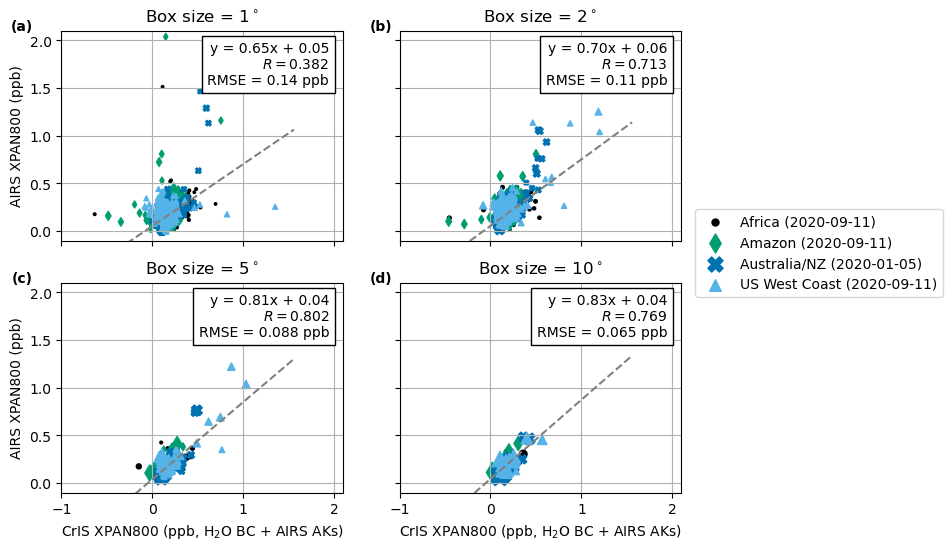

In [27]:
box_sizes = [1, 2, 5, 10]
n_boxes = len(box_sizes)
_, axs = plt.subplots(2, 2, figsize=(8, 6), sharey=True, sharex=True)
binned_points = dict()
for ax, size in zip(axs.flat, box_sizes):
    binned_points[size] = plot_box_mean_correlation(
        quality_ak_no_bc_split_model,
        combined_val_df_full,
        cris_column='c_hat_pwak_bc',
        box_size=size, with_err=False,
        min_count=10,
        extra_qual_fxn=deqa_and_pca_filter,
        ax=ax
    )
    ax.set_title(f'Box size = {size}$^\\circ$')
    ax.grid(True)

binned_plots_xlim = (-1, 2.1)
ax.set_xlim(binned_plots_xlim)
binned_plots_ylim = (-0.1, 2.1)
ax.set_ylim(binned_plots_ylim)

ax.legend(loc='lower left', bbox_to_anchor=(1.025, 0.9))
jplt.label_subplots(axs[:,0], seq='ac', ypos=1)
jplt.label_subplots(axs[:,1], seq='bd', ypos=1, xpos=-0.025)
for ax in axs[0]:
    ax.set_xlabel('')
for ax in axs[:,1]:
    ax.set_ylabel('')

if SAVE_PLOTS:
    plt.savefig('img/airs-cris-correlation.pdf', bbox_inches='tight')

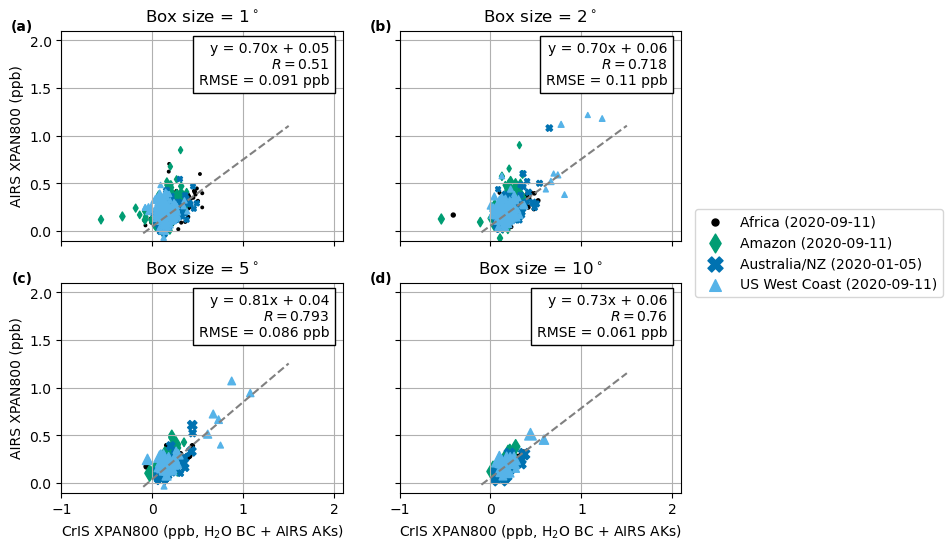

In [28]:
box_sizes = [1, 2, 5, 10]
n_boxes = len(box_sizes)
_, axs = plt.subplots(2, 2, figsize=(8, 6), sharey=True, sharex=True)
for ax, size in zip(axs.flat, box_sizes):
    plot_box_mean_correlation(
        quality_ak_no_bc_joint_model,
        combined_val_df_full,
        cris_column='c_hat_pwak_bc',
        box_size=size, with_err=False,
        min_count=10,
        extra_qual_fxn=deqa_and_pca_filter,
        fit_xlim=[-0.1, 1.5],
        ax=ax
    )
    ax.set_title(f'Box size = {size}$^\\circ$')
    ax.grid(True)

binned_plots_xlim = (-1, 2.1)
ax.set_xlim(binned_plots_xlim)
binned_plots_ylim = (-0.1, 2.1)
ax.set_ylim(binned_plots_ylim)

ax.legend(loc='lower left', bbox_to_anchor=(1.025, 0.9))
jplt.label_subplots(axs[:,0], seq='ac', ypos=1)
jplt.label_subplots(axs[:,1], seq='bd', ypos=1, xpos=-0.025)
for ax in axs[0]:
    ax.set_xlabel('')
for ax in axs[:,1]:
    ax.set_ylabel('')

if SAVE_PLOTS:
    plt.savefig('img/airs-cris-correlation-joint-model.pdf', bbox_inches='tight')

Since we fixed the $x$ and $y$ limits for the plots, confirm whether too many points went outside the plot limits.

In [302]:
# Check how many points are off the axes for each panel
for size, stat_df in binned_points.items():
    n = np.sum( (stat_df.x < binned_plots_xlim[0]) | (stat_df.x > binned_plots_xlim[1]) | (stat_df.y < binned_plots_ylim[0]) | (stat_df.y > binned_plots_ylim[1]) )
    print(f'{size} deg box has {n} of {stat_df.shape[0]} points outside the plot limits')

1 deg box has 1 of 1720 points outside the plot limits
2 deg box has 0 of 865 points outside the plot limits
5 deg box has 0 of 218 points outside the plot limits
10 deg box has 0 of 76 points outside the plot limits


This is the raw version of Table 6 in the paper.
For the paper, we manually round to 3 significant figures.

In [303]:
print(num_soundings_per_box_table(binned_points).to_latex())

\begin{tabular}{lrrrrr}
\toprule
{} &  1st pct. &  25th pct. &  Median &  75th pct. &  99th pct. \\
\midrule
1  &      10.0 &      12.00 &    15.0 &      22.00 &      46.00 \\
2  &      10.0 &      23.00 &    38.0 &      58.00 &     154.36 \\
5  &      12.0 &      62.25 &   137.0 &     248.00 &     747.03 \\
10 &      25.0 &     150.00 &   406.0 &     641.75 &    2142.00 \\
\bottomrule
\end{tabular}



Next we plot the correlation of AIRS and CrIS XPAN without any averaging (Fig. 11).
This is mainly for comparison to the error analysis.

In [304]:
def plot_single_sounding_correlation(model_eval: ModelEval, val_df_full: pd.DataFrame, cris_column: str,
                                     extra_qual_fxn=None, extent=None, ax=None):
    if model_eval is not None:
        is_good_predict = model_eval.predict(val_df_full)
    else:
        is_good_predict = np.ones(val_df_full.shape[0], dtype=bool)

    if extra_qual_fxn is not None:
        is_good_predict &= extra_qual_fxn(val_df_full)

    x = val_df_full.loc[is_good_predict, cris_column].to_numpy()
    y = val_df_full.loc[is_good_predict, 'xpan_airs'].to_numpy()
    ax = ax or plt.gca()
    h = ax.hexbin(x, y, mincnt=1, bins='log', cmap='PuBu', extent=extent)
    plt.colorbar(h, ax=ax, label='# soundings')
    ax.grid(True)
    ax.set_xlabel(CRIS_LABELS.get(cris_column, cris_column))
    ax.set_ylabel('AIRS XPAN800 (ppb)')

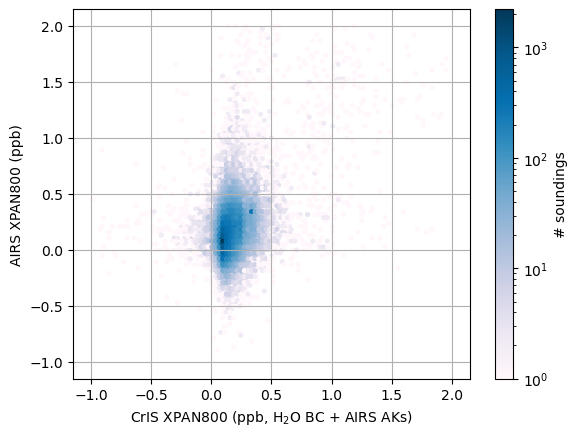

In [305]:
plot_single_sounding_correlation(
    quality_ak_no_bc_split_model,
    combined_val_df_full,
    'c_hat_pwak_bc',
    extra_qual_fxn=deqa_and_pca_filter,
    extent=[-1, 2, -1, 2]
)
if SAVE_PLOTS:
    plt.savefig('img/single-sounding-corr.png', bbox_inches='tight')
    plt.savefig('img/single-sounding-corr.pdf', bbox_inches='tight')


### African desert

This section creates Figs. 7 and B1 in the paper.
These plots address remaining issues with surface emissivity affecting the retrieval even with the decision tree filter.

In [290]:
def plot_single_sounding_map(val_df_full: pd.DataFrame, xpan_column: str, model_eval: ModelEval, test_key: str, extra_qual_fxn=None,
                             use_cris_coords=False, ax=None, clabel=None, add_states=False, **scatter_kws):
    kk = val_df_full.test_key == test_key
    plot_df = _map_df_prep(val_df_full.loc[kk,:], model_eval, box_size=None, extra_qual_fxn=extra_qual_fxn)
    if ax is None:
        _, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()})

    scatter_kws.setdefault('s', 1)
    if use_cris_coords:
        lon = plot_df.lon_cris
        lat = plot_df.lat_cris
    else:
        lon = plot_df.lon_airs
        lat = plot_df.lat_airs
    h = ax.scatter(lon, lat, c=plot_df[xpan_column], **scatter_kws)
    plt.colorbar(h, ax=ax, label=clabel or xpan_column)
    gl = ax.gridlines(draw_labels=True)
    gl.right_labels=False
    gl.top_labels=False
    ax.coastlines()
    ax.add_feature(cfeat.BORDERS)
    if add_states:
        ax.add_feature(cfeat.STATES)


def _map_df_prep(val_df_full, model_eval, box_size, extra_qual_fxn):
    if model_eval is not None:
        is_good_predict = model_eval.predict(val_df_full)
    else:
        is_good_predict = np.ones(val_df_full.shape[0], dtype=bool)
        
    if extra_qual_fxn is not None:
        is_good_predict &= extra_qual_fxn(val_df_full)

    val_df_full = val_df_full.loc[is_good_predict, :].copy()
    if box_size is not None:
        return assign_lat_lon_boxes(val_df_full, box_size=box_size)
    else:
        return val_df_full
    

def plot_camel_emissivity_in_box(l2_file, extent, color='black', include_spread=True, ax=None, **plot_kws):
    freq_grid, emis = _get_hsr_emissivity(l2_file, extent)

    if np.all(np.isnan(emis)):
        print('emis is all NaNs!')
    
    mean_emis = np.nanmean(emis, axis=0)
    std_emis = np.nanstd(emis, axis=0, ddof=1)
    upper_emis = mean_emis + std_emis
    lower_emis = mean_emis - std_emis

    ax = ax or plt.gca()
    ax.plot(freq_grid, mean_emis, color=color, **plot_kws)
    if include_spread:
        ax.fill_between(freq_grid, lower_emis, upper_emis, alpha=0.25, color=color)
    ax.set_xlabel('Frequency (cm$^{-1}$)')
    ax.set_ylabel('Emissivity (unitless)')
    ax.grid(True)

def _get_hsr_emissivity(l2_file, extent, return_original=False):
    with Dataset(l2_file) as ds:
        lon = readers.get_nc_var(ds, 'Longitude')
        lat = readers.get_nc_var(ds, 'Latitude')
        emissivity = readers.get_nc_var(ds, 'Characterization/Native_HSR_Emissivity_Initial')
        freq_grid = readers.get_nc_var(ds, 'Characterization/Native_HSR_Emis_Wavenumber')

    # The emissivity and its frequency grid are padded with fill values, so make sure
    # that the padding is consistent within our extent, and that the frequency grid is
    # as well
    lonmin, lonmax, latmin, latmax = extent
    xx = (lon >= lonmin) & (lon <= lonmax)
    yy = (lat >= latmin) & (lat <= latmax)
    emissivity = emissivity[xx & yy, :]
    freq_grid = freq_grid[xx & yy, :]
    freq_grid_out, emissivity_out = _interp_to_common_grid(freq_grid, emissivity)

    if return_original:
        return freq_grid_out, emissivity_out, freq_grid, emissivity
    else:
        return freq_grid_out, emissivity_out


def _interp_to_common_grid(freq, emis):
    unique_freq = np.unique(freq[freq > -990])
    n_soundings = emis.shape[0]
    n_freq = unique_freq.size
    emis_out = np.full([n_soundings, n_freq], np.nan)

    for i, (this_freq, this_emis) in tqdm(enumerate(zip(freq, emis))):
        xx = this_freq > -990
        if not np.any(xx):
            continue
        assert np.array_equal(xx, this_emis > -990)
        f = interp1d(this_freq[xx], this_emis[xx], bounds_error=False)
        emis_out[i] = f(unique_freq)

    return unique_freq, emis_out


def add_spectral_feature(specie, ax=None, spectral_signature_file='data/spectral-signatures.nc', **style):
    with Dataset(spectral_signature_file) as ds:
        freq = ds['frequency'][:].filled(np.nan)
        bt = ds[f'{specie}_delta_brightness_temperature'][:].filled(np.nan)

    ax = ax or plt.gca()
    ax.plot(freq, bt, **style)

3869it [00:00, 54770.60it/s]
2047it [00:00, 49371.71it/s]
3869it [00:00, 51544.85it/s]
2047it [00:00, 53336.52it/s]


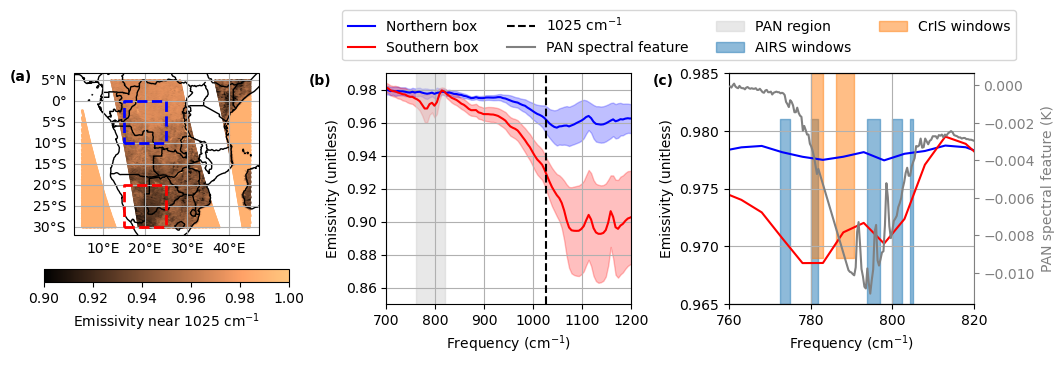

In [291]:
northern_box = [15, 25, -10, 0]
southern_box = [15, 25, -30, -20]
pan_window = [760, 820]
fig = plt.figure(figsize=(12,3))
all_axs = []
ax = fig.add_subplot(1,3,1,projection=ccrs.PlateCarree())
all_axs.append(ax)
quick_plots.plot_sounding_map_from_combined(
    combined_file='data/validation/airs-runs/airs/2020-09-11/combine/African_Fires_PAN/Products_L2-PAN-0.nc',
    variable='Characterization/Desert_Emiss_QA',
    map_features=[cfeat.COASTLINE, cfeat.BORDERS],
    cblabel='Emissivity near 1025 cm$^{-1}$',
    s=1, cmap='copper', vmin=0.9, vmax=1.0,
    cb_kws={'orientation': 'horizontal'},
    ax=ax
)
plot_box(*northern_box, ax=ax, color='blue', ls='--', lw=2)
plot_box(*southern_box, ax=ax, color='red', ls='--', lw=2)

ax = fig.add_subplot(1,3,2)
all_axs.append(ax)
plot_camel_emissivity_in_box(
    l2_file='data/validation/airs-runs/airs/2020-09-11/combine/African_Fires_PAN/Products_L2-PAN-0.nc',
    extent=northern_box,
    label='Northern box',
    color='blue',
    ax=ax
)

plot_camel_emissivity_in_box(
    l2_file='data/validation/airs-runs/airs/2020-09-11/combine/African_Fires_PAN/Products_L2-PAN-0.nc',
    extent=southern_box,
    label='Southern box',
    color='red',
    ax=ax
)

# ax.axvline(795, color='gray', ls='-.', label='PAN feature center')
h_pan = ax.fill_betweenx([0.8, 1.0], *pan_window, color='lightgray', alpha=0.5, label='PAN region')
ax.axvline(1025, color='black', ls='--', label='1025 cm$^{-1}$')
ax.set_xlim(700, 1200)
ax.set_ylim(0.85, 0.99)
plt.subplots_adjust(wspace=0.33)


ax = fig.add_subplot(1,3,3)
all_axs.append(ax)
plot_camel_emissivity_in_box(
    l2_file='data/validation/airs-runs/airs/2020-09-11/combine/African_Fires_PAN/Products_L2-PAN-0.nc',
    extent=northern_box,
    label='Northern box',
    include_spread=False,
    color='blue',
    ax=ax
)

plot_camel_emissivity_in_box(
    l2_file='data/validation/airs-runs/airs/2020-09-11/combine/African_Fires_PAN/Products_L2-PAN-0.nc',
    extent=southern_box,
    label='Southern box',
    include_spread=False,
    color='red',
    ax=ax
)

_, _, ax2 = jplt.create_twin_axes_with_color(color2='gray', ax=ax)
add_spectral_feature('pan', ax=ax2, color='gray')
ax2.set_ylabel('PAN spectral feature (K)')
ax.set_xlim(*pan_window)
ax.set_ylim(0.965, 0.985)
h_airs = _plot_windows(AIRS_WINDOWS, ax=ax, half='top-offset', color='tab:blue', label='AIRS windows')
h_cris = _plot_windows(CRIS_WINDOWS, ax=ax, half='bottom-offset', color='tab:orange', label='CrIS windows')

handles = [
    Line2D([0], [0], color='blue', label='Northern box'),
    Line2D([0], [0], color='red', label='Southern box'),
    Line2D([0], [0], color='black', ls='--', label='1025 cm$^{-1}$'),
    Line2D([0], [0], color='gray', label='PAN spectral feature'),
    h_pan,
    h_airs,
    h_cris,
]
ax.legend(handles=handles, loc='lower right', ncol=4, bbox_to_anchor=(1.2, 1.025))

plt.subplots_adjust(wspace=0.4)
jplt.label_subplots(all_axs, xpos=-0.225)
if SAVE_PLOTS:
    plt.savefig('img/desert-emiss-explanation.png', bbox_inches='tight')
    plt.savefig('img/desert-emiss-explanation.pdf', bbox_inches='tight')

Calculating XPAN800 [######################################] 34641/34641


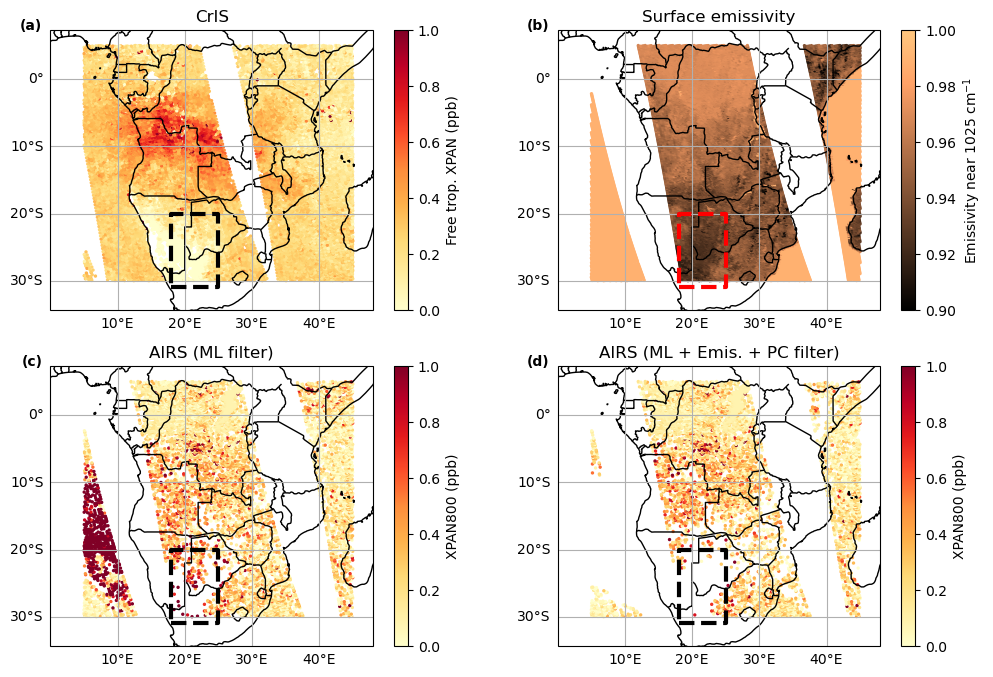

In [306]:
_, axs = plt.subplots(2, 2, figsize=(12,8), subplot_kw={'projection': ccrs.PlateCarree()}, gridspec_kw={'wspace': 0.20})

ax = axs[0,0]
cris_qual_filter = quality.StdFlagQualityFilterer('Quality')
quick_plots.plot_sounding_map_from_combined(
    combined_file='data/validation/airs-runs/cris/2020-09-11/combine/African_Fires_PAN/Products_L2-PAN-0.nc',
    variable=quick_plot_xpan800,
    map_features=[cfeat.COASTLINE, cfeat.BORDERS],
    bias_corr=quality.CrisXpanBiasCorr(),
    filterer=cris_qual_filter,
    vmin=0, vmax=1, s=2,
    cblabel='Free trop. XPAN (ppb)',
    cmap='YlOrRd',
    ax=ax
)
ax.set_title('CrIS')

ax = axs[1,0]
plot_single_sounding_map(
    combined_val_df_full,
    'xpan_airs',
    quality_ak_no_bc_split_model,
    test_key='afr-sep11',
    extra_qual_fxn=None,
    clabel='XPAN800 (ppb)',
    use_cris_coords=False,
    vmin=0, vmax=1, s=2, ax=ax,
    cmap='YlOrRd'
)
ax.set_title('AIRS (ML filter)')

ax = axs[1,1]
plot_single_sounding_map(
    combined_val_df_full,
    'xpan_airs',
    quality_ak_no_bc_split_model,
    test_key='afr-sep11',
    extra_qual_fxn=deqa_and_pca_filter,
    clabel='XPAN800 (ppb)',
    use_cris_coords=False,
    vmin=0, vmax=1, s=2, ax=ax,
    cmap='YlOrRd'
)
ax.set_title('AIRS (ML + Emis. + PC filter)')

ax = axs[0,1]
plot_single_sounding_map(
    combined_val_df_full,
    'Desert_Emiss_QA',
    model_eval=None,
    test_key='afr-sep11',
    extra_qual_fxn=None,
    clabel='Emissivity near 1025 cm$^{-1}$',
    cmap='copper',
    vmin=0.9, vmax=1, s=2, ax=ax
)
ax.set_title('Surface emissivity')
for iax, ax in enumerate(axs.flat):
    ax.set_extent([0, 48, -32, 7])
    plot_box(18, 25, -31, -20, ax=ax, ls='--', color='r' if iax == 1 else 'k', lw=3)
jplt.label_subplots(axs.flatten(), xpos=-0.025, ypos=1)

if SAVE_PLOTS:
    plt.savefig('img/africa-emis-filter.png', bbox_inches='tight')
    plt.savefig('img/africa-emis-filter.pdf', bbox_inches='tight')


We don't show this in the paper, but this proves that we did run the AIRS soundings over ocean, they are just being filtered out.

### Overall maps

This section creates Fig. 8 to show that AIRS and CrIS do see similar spatial patterns of XPAN, and the CO is an example of a useful cross-check to increase confidence in a PAN plume observed by AIRS.

In [293]:
def plot_pan_co_maps(combined_val_df_full, ml_filter, test_keys=None):
    if test_keys is None:
        test_keys = combined_val_df_full.test_key.unique()
    ny = len(test_keys)
    _, axs = plt.subplots(ny, 3, figsize=(12,3*ny), subplot_kw={'projection': ccrs.PlateCarree()}, gridspec_kw={'wspace': 0.33, 'hspace': 0.33})

    for test_key, ax_row in zip(test_keys, axs):
        plot_pan_co_map_row(test_key, combined_val_df_full, ml_filter, axs=ax_row)

def plot_pan_co_map_row(test_key, combined_val_df_full, ml_filter, axs=None):
    if axs is None:
        _, axs = plt.subplots(1, 3, figsize=(12,3), subplot_kw={'projection': ccrs.PlateCarree()}, gridspec_kw={'wspace': 0.33})
    elif len(axs) != 3:
        raise ValueError('axs must have 3 elements')

    cris_path = aread.test_cases_by_key('cris')[test_key]  # _path_from_test_key(test_key, 'cris')
    airs_path = aread.test_cases_by_key('airs')[test_key]  # _path_from_test_key(test_key, 'airs')
    map_features = [cfeat.COASTLINE, cfeat.BORDERS]
    add_states = False
    if test_key.startswith('wcf'):
        map_features.append(cfeat.STATES)
        add_states = True

    ax = axs[0]
    qual_filter = quality.StdFlagQualityFilterer('Quality')
    quick_plots.plot_sounding_map_from_combined(
        combined_file=cris_path / 'Products_L2-PAN-0.nc',
        variable=quick_plot_xpan800,
        map_features=map_features,
        bias_corr=quality.CrisXpanBiasCorr(),
        filterer=qual_filter,
        vmin=0, vmax=1, s=1,
        cblabel='Free trop. XPAN (ppb)',
        cmap='YlOrRd',
        ax=ax
    )
    ax.set_title('CrIS')

    ax = axs[1]
    plot_single_sounding_map(
        combined_val_df_full,
        'xpan_airs',
        ml_filter,
        test_key=test_key,
        extra_qual_fxn=deqa_and_pca_filter,
        clabel='XPAN800 (ppb)',
        use_cris_coords=False,
        add_states=add_states,
        vmin=0, vmax=1, s=1, ax=ax,
        cmap='YlOrRd'
    )
    ax.set_title('AIRS PAN')

    ax = axs[2]
    quick_plots.plot_sounding_map_from_combined(
        combined_file=airs_path / 'Products_L2-CO-0.nc',
        variable='Retrieval/Column',
        dim2_idx=0,
        map_features=map_features,
        bias_corr=quality.CrisXpanBiasCorr(),
        filterer=qual_filter,
        vmin=0, vmax=1e19, s=1,
        cblabel='CO total col. (molec. cm$^{-2}$)',
        cmap=cmr.gem,
        ax=ax
    )
    ax.set_title('AIRS CO')

def _path_from_test_key(test_key, instr, root='../static-data/validation/airs-runs/'):
    profile_map = {
        'aus': 'Australian_Fires_PAN',
        'wcf': 'West_Coast_Fires_Pacific',
        'ama': 'Amazon_Fires_PAN',
        'afr': 'African_Fires_PAN'
    }
    date = _date_from_test_key(test_key)
    profile = profile_map[test_key.split('-')[0]]
    return Path(root) / instr / date.strftime('%Y-%m-%d') / 'combine' / profile

def _date_from_test_key(test_key):
    tmp = pd.to_datetime(test_key.split('-', maxsplit=1)[1], format='%b%d')
    return pd.Timestamp(2020, tmp.month, tmp.day)

Calculating XPAN800 [######################################] 52279/52279
Calculating XPAN800 [######################################] 38236/38236
Calculating XPAN800 [######################################] 27753/27753
Calculating XPAN800 [######################################] 34641/34641


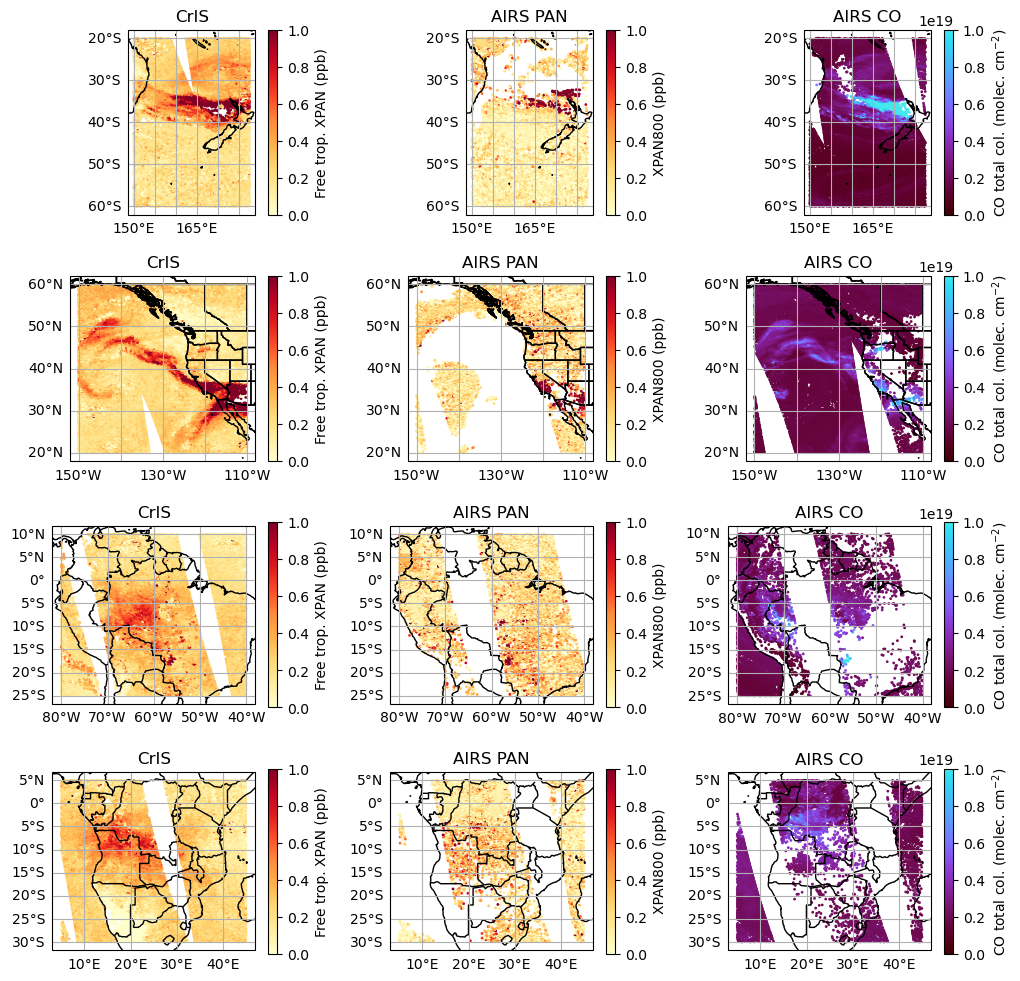

In [307]:
plot_pan_co_maps(combined_val_df_full, quality_ak_no_bc_split_model)
if SAVE_PLOTS:
    plt.savefig('img/pan-co-maps.png', bbox_inches='tight')
    plt.savefig('img/pan-co-maps.pdf', bbox_inches='tight')


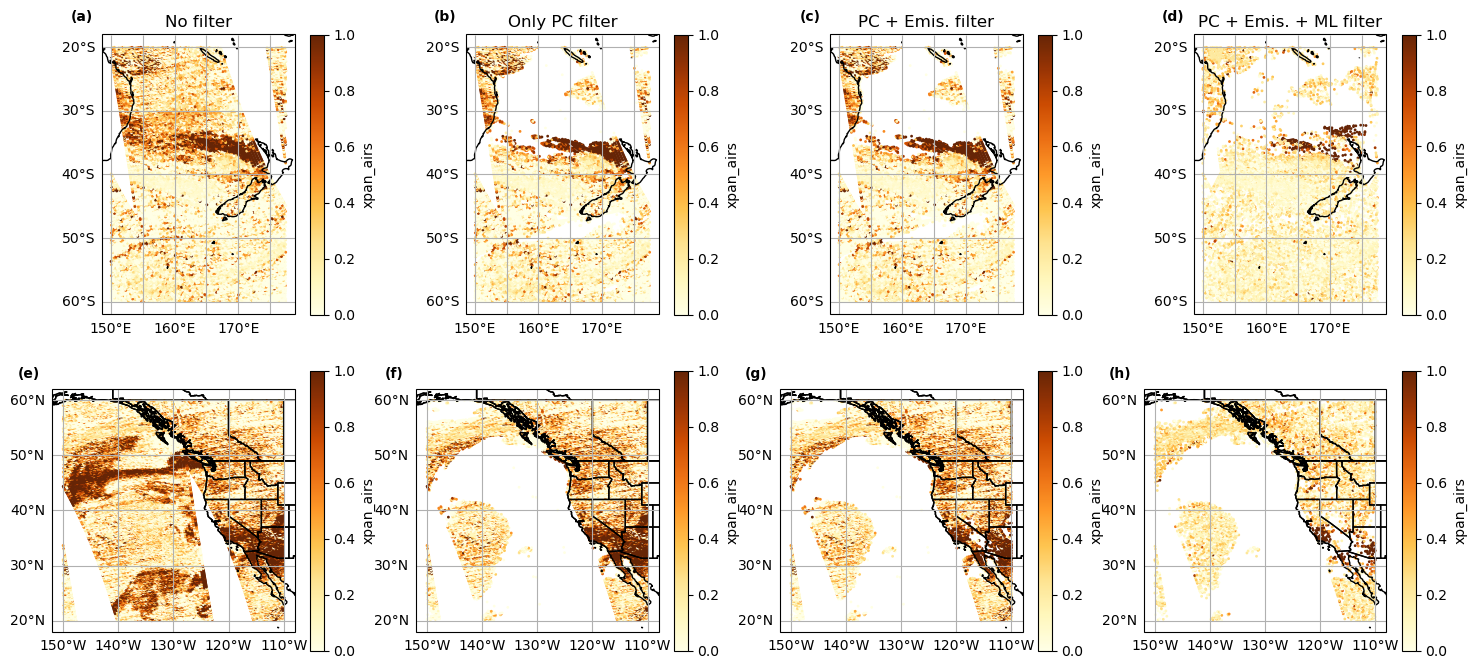

In [308]:
_, axs = plt.subplots(2,4,figsize=(18,8),subplot_kw={'projection': ccrs.PlateCarree()})

ax = axs[0,0]
plot_single_sounding_map(
    val_df_full=combined_val_df_full,
    xpan_column='xpan_airs',
    model_eval=None,
    test_key='aus-jan05',
    extra_qual_fxn=lambda df: df.dayflag_airs == 1,
    vmin=0, vmax=1, cmap='YlOrBr',
    ax=ax
)
ax.set_title('No filter')

ax = axs[0,1]
plot_single_sounding_map(
    val_df_full=combined_val_df_full,
    xpan_column='xpan_airs',
    model_eval=None,
    test_key='aus-jan05',
    extra_qual_fxn=lambda df: df.pca_filter & df.dayflag_airs,
    vmin=0, vmax=1, cmap='YlOrBr',
    ax=ax
)
ax.set_title('Only PC filter')

ax = axs[0,2]
plot_single_sounding_map(
    val_df_full=combined_val_df_full,
    xpan_column='xpan_airs',
    model_eval=None,
    test_key='aus-jan05',
    extra_qual_fxn=lambda df: deqa_and_pca_filter(df) & df.dayflag_airs,
    vmin=0, vmax=1, cmap='YlOrBr',
    ax=ax
)
ax.set_title('PC + Emis. filter')

ax = axs[0,3]
plot_single_sounding_map(
    val_df_full=combined_val_df_full,
    xpan_column='xpan_airs',
    model_eval=quality_ak_no_bc_split_model,
    test_key='aus-jan05',
    extra_qual_fxn=deqa_and_pca_filter,
    vmin=0, vmax=1, cmap='YlOrBr',
    ax=ax
)
ax.set_title('PC + Emis. + ML filter')

ax = axs[1,0]
plot_single_sounding_map(
    val_df_full=combined_val_df_full,
    xpan_column='xpan_airs',
    model_eval=None,
    test_key='wcf-sep11',
    extra_qual_fxn=lambda df: df.dayflag_airs == 1,
    vmin=0, vmax=1, cmap='YlOrBr',
    add_states=True,
    ax=ax
)

ax = axs[1,1]
plot_single_sounding_map(
    val_df_full=combined_val_df_full,
    xpan_column='xpan_airs',
    model_eval=None,
    test_key='wcf-sep11',
    extra_qual_fxn=lambda df: df.pca_filter & df.dayflag_airs,
    vmin=0, vmax=1, cmap='YlOrBr',
    add_states=True,
    ax=ax
)

ax = axs[1,2]
plot_single_sounding_map(
    val_df_full=combined_val_df_full,
    xpan_column='xpan_airs',
    model_eval=None,
    test_key='wcf-sep11',
    extra_qual_fxn=lambda df: deqa_and_pca_filter(df) & df.dayflag_airs,
    vmin=0, vmax=1, cmap='YlOrBr',
    add_states=True,
    ax=ax
)

ax = axs[1,3]
plot_single_sounding_map(
    val_df_full=combined_val_df_full,
    xpan_column='xpan_airs',
    model_eval=quality_ak_no_bc_split_model,
    test_key='wcf-sep11',
    extra_qual_fxn=deqa_and_pca_filter,
    vmin=0, vmax=1, cmap='YlOrBr',
    add_states=True,
    ax=ax
)

jplt.label_subplots(axs.flatten(), ypos=1.05, xpos=-0.05)

if SAVE_PLOTS:
    plt.savefig('img/filter-progression.pdf', bbox_inches='tight')
    plt.savefig('img/filter-progression.png', bbox_inches='tight')

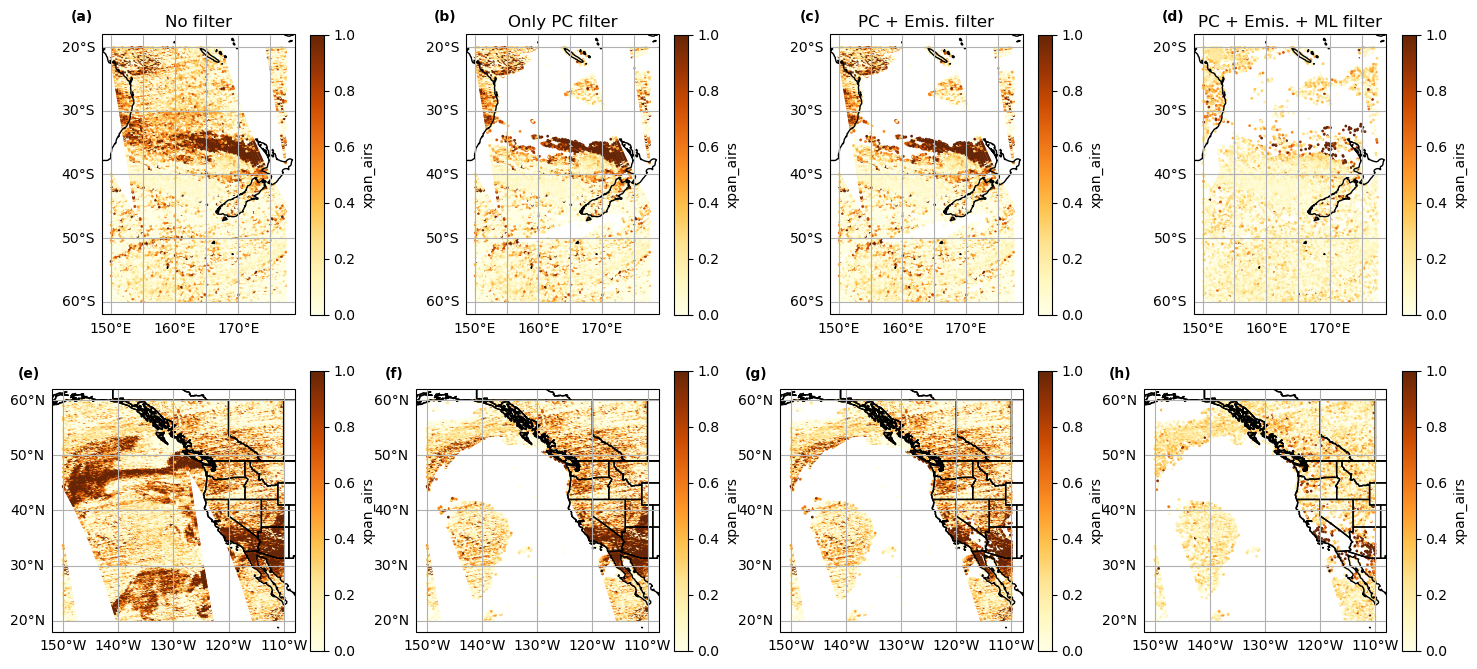

In [309]:
_, axs = plt.subplots(2,4,figsize=(18,8),subplot_kw={'projection': ccrs.PlateCarree()})

ax = axs[0,0]
plot_single_sounding_map(
    val_df_full=combined_val_df_full,
    xpan_column='xpan_airs',
    model_eval=None,
    test_key='aus-jan05',
    extra_qual_fxn=lambda df: df.dayflag_airs == 1,
    vmin=0, vmax=1, cmap='YlOrBr',
    ax=ax
)
ax.set_title('No filter')

ax = axs[0,1]
plot_single_sounding_map(
    val_df_full=combined_val_df_full,
    xpan_column='xpan_airs',
    model_eval=None,
    test_key='aus-jan05',
    extra_qual_fxn=lambda df: df.pca_filter & df.dayflag_airs,
    vmin=0, vmax=1, cmap='YlOrBr',
    ax=ax
)
ax.set_title('Only PC filter')

ax = axs[0,2]
plot_single_sounding_map(
    val_df_full=combined_val_df_full,
    xpan_column='xpan_airs',
    model_eval=None,
    test_key='aus-jan05',
    extra_qual_fxn=lambda df: deqa_and_pca_filter(df) & df.dayflag_airs,
    vmin=0, vmax=1, cmap='YlOrBr',
    ax=ax
)
ax.set_title('PC + Emis. filter')

ax = axs[0,3]
plot_single_sounding_map(
    val_df_full=combined_val_df_full,
    xpan_column='xpan_airs',
    model_eval=quality_ak_no_bc_joint_model,
    test_key='aus-jan05',
    extra_qual_fxn=deqa_and_pca_filter,
    vmin=0, vmax=1, cmap='YlOrBr',
    ax=ax
)
ax.set_title('PC + Emis. + ML filter')

ax = axs[1,0]
plot_single_sounding_map(
    val_df_full=combined_val_df_full,
    xpan_column='xpan_airs',
    model_eval=None,
    test_key='wcf-sep11',
    extra_qual_fxn=lambda df: df.dayflag_airs == 1,
    vmin=0, vmax=1, cmap='YlOrBr',
    add_states=True,
    ax=ax
)

ax = axs[1,1]
plot_single_sounding_map(
    val_df_full=combined_val_df_full,
    xpan_column='xpan_airs',
    model_eval=None,
    test_key='wcf-sep11',
    extra_qual_fxn=lambda df: df.pca_filter & df.dayflag_airs,
    vmin=0, vmax=1, cmap='YlOrBr',
    add_states=True,
    ax=ax
)

ax = axs[1,2]
plot_single_sounding_map(
    val_df_full=combined_val_df_full,
    xpan_column='xpan_airs',
    model_eval=None,
    test_key='wcf-sep11',
    extra_qual_fxn=lambda df: deqa_and_pca_filter(df) & df.dayflag_airs,
    vmin=0, vmax=1, cmap='YlOrBr',
    add_states=True,
    ax=ax
)

ax = axs[1,3]
plot_single_sounding_map(
    val_df_full=combined_val_df_full,
    xpan_column='xpan_airs',
    model_eval=quality_ak_no_bc_joint_model,
    test_key='wcf-sep11',
    extra_qual_fxn=deqa_and_pca_filter,
    vmin=0, vmax=1, cmap='YlOrBr',
    add_states=True,
    ax=ax
)

jplt.label_subplots(axs.flatten(), ypos=1.05, xpos=-0.05)

if SAVE_PLOTS:
    plt.savefig('img/filter-progression-joint.pdf', bbox_inches='tight')
    plt.savefig('img/filter-progression-joint.png', bbox_inches='tight')

### Explainable AI

This section creates Fig. A1 from the paper that uses Shapley values to understand what inputs most determine whether the decision tree flags a sounding.
See https://shap.readthedocs.io/en/latest/ for more information on Shapley Additive Explanations.

In [310]:
FEATURE_DISPLAY_NAMES = {
    'ResidualNormInitial': 'Res. Norm. Init.',
    'ResidualNormFinal': 'Res. Norm. Final',
    'RadianceMaximumSNR': 'Rad. Max. SNR',
    'KdotDL': 'K $\\cdot$ dL',
    'LdotDL': 'L $\\cdot$ dL',
    'PCLOUD': 'Cld. pres.',
    'CLOUD_VAR': 'Cld. OD var.',
    'EMIS_MEAN': 'Mean surf. emis.',
    'Desert_Emiss_QA': 'Desert emis.',
    'H2O_H2O_Quality': 'H$_2$O self corr.',
    'TATM_Propagated': 'Atm. T quality',
    'O3_Propagated': 'O$_3$ quality',
    'H2O_Propagated': 'H$_2$O quality',
    'radianceResidualRMS': 'Rad. resid. std. dev.',
    'radianceResidualMean': 'Rad. resid. mean',
    'CLOUD_MEAN': 'Cld. OD mean'
}

def make_shapley_values(training_df_full, model_eval_obj: ModelEval, ocean_model: bool = False, expl_fraction: float = 0.1):
    X = model_eval_obj.features.subset_df(training_df_full)
    n_expl = int(X.shape[0] * expl_fraction)
    X_expl = shap.utils.sample(X, n_expl).to_numpy()
    model = model_eval_obj.ocean_model if ocean_model else model_eval_obj.land_model
    explainer = shap.Explainer(model.predict, X_expl)
    shap_values = explainer(X.to_numpy())
    return shap_values


def assign_shapley_feature_names(shap_values: shap.Explanation, model_eval_obj):
    shap_values = deepcopy(shap_values)
    names = [FEATURE_DISPLAY_NAMES[k] for k in model_eval_obj.features.colnames]
    shap_values.feature_names = names
    return shap_values

In [314]:
shap_values_land = make_shapley_values(training_df_full.dropna(), quality_ak_no_bc_split_model, ocean_model=False)
shap_values_ocean = make_shapley_values(training_df_full.dropna(), quality_ak_no_bc_split_model, ocean_model=True)

PermutationExplainer explainer: 84798it [04:26, 304.95it/s]                                                                                                                                                    
PermutationExplainer explainer: 84798it [04:55, 276.88it/s]                                                                                                                                                    


In [315]:
named_shap_values_land = assign_shapley_feature_names(shap_values_land, quality_ak_no_bc_split_model)
named_shap_values_ocean = assign_shapley_feature_names(shap_values_ocean, quality_ak_no_bc_split_model)

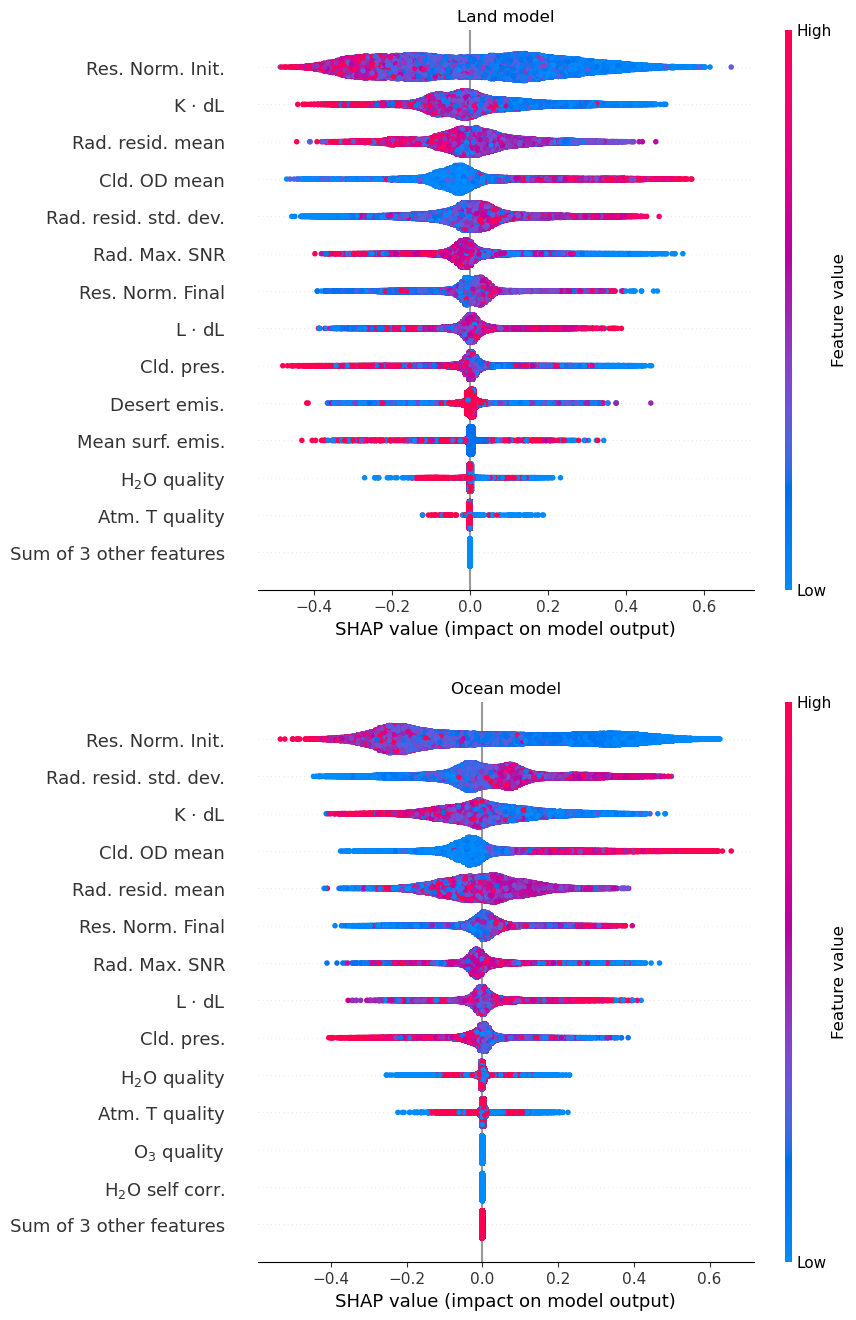

In [321]:
_, axs = plt.subplots(2, 1, figsize=(8,16))

ax = axs[0]
shap.plots.beeswarm(named_shap_values_land, max_display=14, show=False, ax=ax, plot_size=None)
ax.set_title('Land model')

ax = axs[1]
shap.plots.beeswarm(named_shap_values_ocean, max_display=14, show=False, ax=ax, plot_size=None)
ax.set_title('Ocean model')

if SAVE_PLOTS:
    plt.savefig('img/ml-beeswarm.png', bbox_inches='tight')
    plt.savefig('img/ml-beeswarm.pdf', bbox_inches='tight')

## AIRS to CrIS noise comparison

Finally, this section compares the radiance noise between AIRS and CrIS in the window used to retrieve PAN (Fig. 10).

In [145]:
def load_nesr(rad_file, case=None):
    with Dataset(rad_file) as ds:
        freq = aread._get_nc_var(ds, 'FREQUENCY')
        rad = aread._get_nc_var(ds, 'RADIANCEOBSERVED')
        nesr = aread._get_nc_var(ds, 'NESR')

    arrs = {
        'freq': xr.DataArray(freq, dims=['sounding', 'channel']),
        'rad': xr.DataArray(rad, dims=['sounding', 'channel']),
        'nesr': xr.DataArray(nesr, dims=['sounding', 'channel']),
    }
    arrs['rad_bt'] = aread._to_brightness_temperature(arrs['freq'], arrs['rad'])

    # BT is nonlinear w.r.t. radiance, so compute the noise as the difference in the
    # radiance plus and minus 1/2 the noise
    rad_plus_half_nesr_bt = aread._to_brightness_temperature(arrs['freq'], arrs['rad'] + 0.5*arrs['nesr'])
    rad_minus_half_nesr_bt = aread._to_brightness_temperature(arrs['freq'], arrs['rad'] - 0.5*arrs['nesr'])
    arrs['nesr_bt'] = np.abs(rad_plus_half_nesr_bt - rad_minus_half_nesr_bt)
    if case is not None:
        arrs['case'] = xr.DataArray([case]*freq.shape[0], dims=['sounding'])
    return xr.Dataset(arrs)


def load_nesr_many_cases(cases=('aus-jan01', 'aus-jan05', 'wcf-sep11', 'wcf-sep13', 'ama-sep11', 'afr-sep11')):
    airs_test_paths = aread.test_cases_by_key('airs')
    cris_test_paths = aread.test_cases_by_key('cris')
    airs_dsets = []
    cris_dsets = []
    for key in cases:
        print(f'Loading {key}')
        airs_path = airs_test_paths[key] / 'Products_Radiance-PAN.nc'
        cris_path = cris_test_paths[key] / 'Products_Radiance-PAN.nc'
        airs_dsets.append(load_nesr(airs_path, case=key))
        cris_dsets.append(load_nesr(cris_path, case=key))

    airs_ds = xr.concat(airs_dsets, dim='sounding')
    cris_ds = xr.concat(cris_dsets, dim='sounding')
    return airs_ds, cris_ds


def plot_nesr_median_and_quantiles(nesr_dset, instrument, relative=False, use_bt=True, quantile_range=0.25, color='tab:blue', quantile_color=None, ax=None):
    ax = ax or plt.gca()
    freq = nesr_dset.freq.median(dim='sounding')
    
    if relative:
        noise = nesr_dset.nesr / nesr_dset.rad * 100
        ylabel = 'NESR as percent of radiance'
    elif use_bt:
        noise = nesr_dset.nesr_bt
        ylabel = 'NESR (K)'
    else:
        noise = nesr_dset.nesr
        ylabel = 'NESR (W cm$^{-2}$ cm sr$^{-1}$)'
    med = noise.median(dim='sounding')
    quants = noise.quantile([0.5 - quantile_range, 0.5+quantile_range], dim='sounding')
    errors = np.abs(quants - med)
    
    p1 = int((0.5 - quantile_range)*100)
    p2 = int((0.5 + quantile_range)*100)
    ax.errorbar(freq, med, yerr=errors, ls='none', color=quantile_color or color, label=f'{instrument} {p1}th-{p2}th percentile')
    ax.plot(freq, med, marker='.', ls='none', color=color, label=f'{instrument} median')
    ax.set_xlabel('Frequency (cm$^{-1}$)')
    ax.set_ylabel(ylabel)


def compute_median_noise_ratio(airs_nesr_dset, cris_nesr_dset):
    median_airs = airs_nesr_dset.nesr.median().item()
    median_cris = cris_nesr_dset.nesr.median().item()
    return median_airs / median_cris

In [146]:
airs_nesr_dset, cris_nesr_dset = load_nesr_many_cases()

Loading aus-jan01
Loading aus-jan05
Loading wcf-sep11
Loading wcf-sep13
Loading ama-sep11
Loading afr-sep11


In [147]:
compute_median_noise_ratio(airs_nesr_dset, cris_nesr_dset)

5.908359858782257

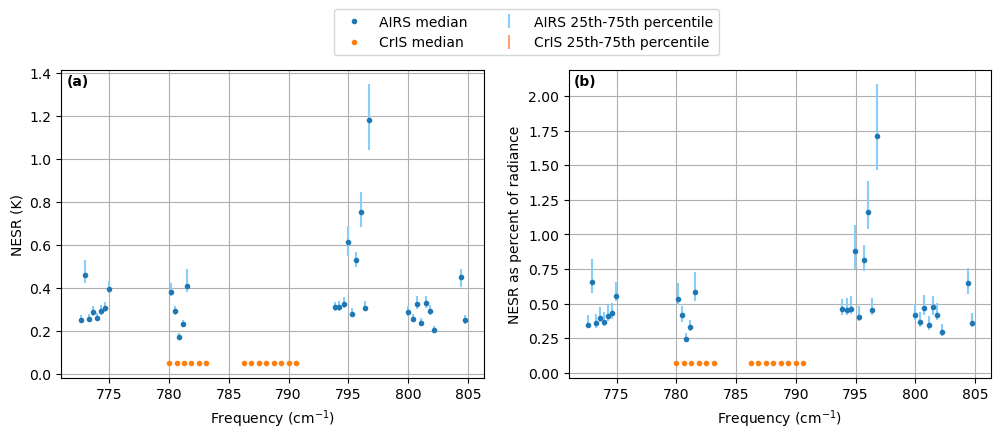

In [148]:
_, axs = plt.subplots(1,2,figsize=(12,4))
ax = axs[0]
plot_nesr_median_and_quantiles(airs_nesr_dset, 'AIRS', color='tab:blue', quantile_color='lightskyblue', ax=ax)
plot_nesr_median_and_quantiles(cris_nesr_dset, 'CrIS', color='tab:orange', quantile_color='lightsalmon', ax=ax)

ax = axs[1]
plot_nesr_median_and_quantiles(airs_nesr_dset, 'AIRS', color='tab:blue', quantile_color='lightskyblue', relative=True, ax=ax)
plot_nesr_median_and_quantiles(cris_nesr_dset, 'CrIS', color='tab:orange', quantile_color='lightsalmon', relative=True, ax=ax)

axs[0].legend(loc='lower center', bbox_to_anchor=(1.1, 1.025), ncol=2)
for ax in axs:
    ax.grid(True)

jplt.label_subplots(axs, xpos=0.065, ypos=0.95)
if SAVE_PLOTS:
    plt.savefig('img/airs-cris-noise-compairson.pdf', bbox_inches='tight')

## A prior profiles and AKs

### Prior profiles

In [3]:
PRIORS_NAME_LABELS = {
    'TROP_ENH_SURF_MAX': 'Enhanced surface (tropics)',
    'OUT_TROP_ENH_SURF_MAX': 'Enhanced surface (extratropics)',
    'TROP_ENH_UP_TROP_MAX': 'Enhanced upper trop. (tropics)',
    'OUT_TROP_ENH_UP_TROP_MAX': 'Enhanced upper trop. (extratropics)',
    'TROP_CLN': 'Clean (tropics)',
    'OUT_TROP_CLN': 'Clean (extratropics)',
}


def plot_pan_priors(clim_file):
    with Dataset(clim_file) as ds:
        type_name_raw = ds['type_name'][:].data
        type_name = readers.convert_sounding_ids(type_name_raw)
        vmr = 1e9 * ds['type_vmr'][:].filled(np.nan)
        pres = ds['pressure'][:].filled(np.nan)
        months = ds['month'][:].data

    cmapper = jplt.ColorMapper.from_discrete_values(months, cmap='twilight')
    n = sum(name != 'Empty' for name in type_name)
    if n != 6:
        raise NotImplementedError('Expected 6 non-empty type names')

    pp = pres <= 1013.25

    gs = GridSpec(nrows=4, ncols=3, height_ratios=[10,10,0.1,1])
    fig = plt.figure(figsize=(12,8))

    plot_positions = {
        'TROP_ENH_SURF_MAX': (0, 1),
        'OUT_TROP_ENH_SURF_MAX': (1, 1),
        'TROP_ENH_UP_TROP_MAX': (0, 2),
        'OUT_TROP_ENH_UP_TROP_MAX': (1, 2),
        'TROP_CLN': (0, 0),
        'OUT_TROP_CLN': (1, 0),
    }
    
    ax0 = None
    for itype, name in enumerate(type_name):
        if name == 'Empty':
            continue

        (ix, iy) = plot_positions[name]
        if ax0 is None:
            ax = fig.add_subplot(gs[ix,iy])
            ax0 = ax
        else:
            ax = fig.add_subplot(gs[ix,iy], sharex=ax0, sharey=ax0)

        if ix == 0:
            plt.setp(ax.get_xticklabels(), visible=False)
        else:
            ax.set_xlabel('PAN mixing ratio (ppb)')
            
        if iy > 0:
            plt.setp(ax.get_yticklabels(), visible=False)
        else:
            ax.set_ylabel('Pressure (hPa)')
            
        for imonth, month in enumerate(months):
            ax.plot(vmr[imonth,itype,pp], pres[pp], color=cmapper(month))
        ax.set_title(PRIORS_NAME_LABELS[name])
        ax.grid(True)

    ax0.set_ylim(1013.25, 0)

    cax = fig.add_subplot(gs[3,1])
    cb = plt.colorbar(cmapper, cax=cax, label='Month', orientation='horizontal', ticks=months)
    cb.set_ticklabels('JFMAMJJASOND')
    plt.subplots_adjust(hspace=0.4)

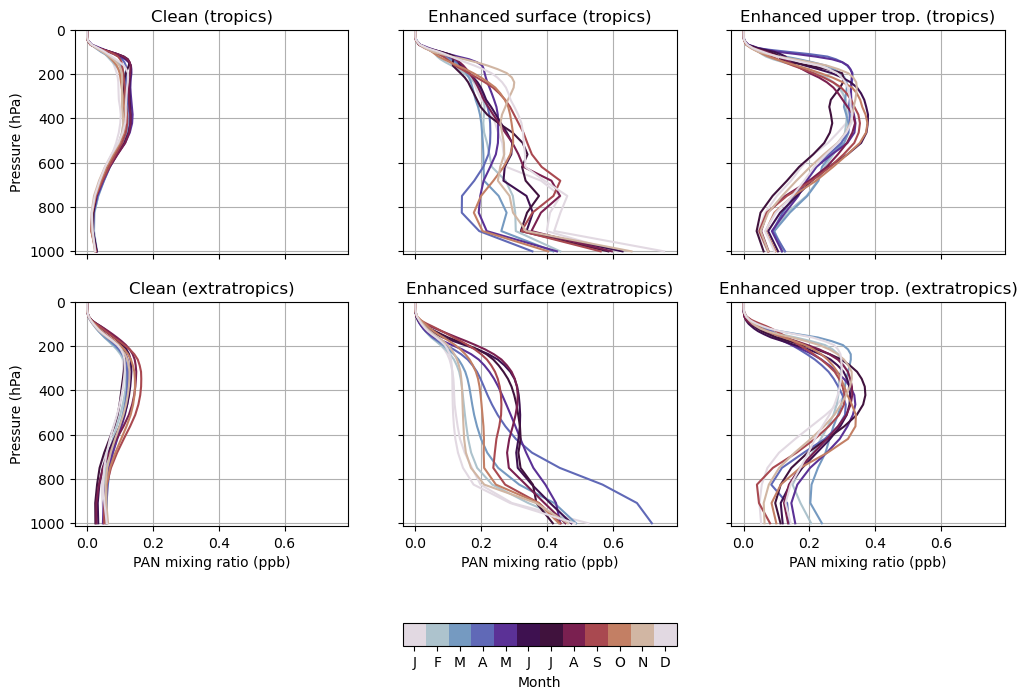

In [39]:
plot_pan_priors('data/climatology_PAN_prior.nc')
if SAVE_PLOTS:
    plt.savefig('img/pan-apriori-profiles.pdf', bbox_inches='tight')

### AKs

In [21]:
def plot_median_aks_binned_by_value(ak_dset, binby, bins, bin_label=None, filter_flag=None, ax=None):
    if filter_flag is not None:
        filter_flag = filter_flag.reindex({'sounding': ak_dset.sounding}).fillna(0).astype(bool)
        ak_dset = ak_dset.sel(sounding=filter_flag)

    binby = binby.reindex({'sounding': ak_dset.sounding})
    bin_mids = 0.5 * (bins[:-1] + bins[1:])
    n_bins = bin_mids.size
    cmapper = jplt.ColorMapper.from_discrete_norm(bins, cmap='plasma')

    ax = ax or plt.gca()
    for i_bin, bin_val in enumerate(bin_mids):
        xx = (binby >= bins[i_bin]) & (binby < bins[i_bin+1])
        subset = ak_dset.sel(sounding=xx)
        med_ak = subset.column_ak.median(dim='sounding')
        med_pres = subset.pressure.median(dim='sounding')

        ax.plot(med_ak, med_pres, color=cmapper(bin_val))

    bin_label = bin_label or binby.name
    plt.colorbar(cmapper, ax=ax, label=bin_label, ticks=bins)

    if not ax.yaxis_inverted():
        ax.invert_yaxis()
    ax.set_xlabel(r'$X_\mathrm{PAN}$ averaging kernel')
    ax.set_ylabel('Pressure (hPa)')
    ax.grid(True)


def load_col_aks_as_xarray(l2_file, normalize=False):
    with Dataset(l2_file) as ds:
        sounding_ids = readers.convert_sounding_ids(readers.get_nc_var(ds, 'SoundingID'))
        p_mat = readers.get_nc_var(ds, 'Pressure')
        ak_mat = readers.get_nc_var(ds, 'AveragingKernel')

    col_ak_mat = np.full_like(p_mat, np.nan)
    pbar = miscutils.ProgressBar(p_mat.shape[0], prefix='Calculating column AKs')
    for i in range(len(sounding_ids)):
        pbar.print_bar()
        p = p_mat[i]
        ak = ak_mat[i]

        is_ok = ~np.isnan(p)
        if np.any(is_ok):
            col_ak_mat[i, is_ok] = aread._compute_x_col_ft_ak(ak[is_ok,:][:,is_ok], p[is_ok], normalize=normalize)

    level = np.arange(p_mat.shape[1])
    data = {
        'pressure': xr.DataArray(p_mat, dims=['sounding', 'level'], coords=[sounding_ids, level]),
        'column_ak': xr.DataArray(col_ak_mat, dims=['sounding', 'level'], coords=[sounding_ids, level]),
    }
    return xr.Dataset(data)


def load_extra_ak_vars(l2_file, instrument):
    with Dataset(l2_file) as ds:
        sounding_ids = readers.convert_sounding_ids(readers.get_nc_var(ds, 'SoundingID'))
        data = dict(
            land_flag = readers.get_nc_var(ds, 'LandFlag'),
            deqa = readers.get_nc_var(ds, 'Characterization/Desert_Emiss_QA'),
            quality_flag = readers.get_nc_var(ds, 'Quality'),
            latitude = readers.get_nc_var(ds, 'Latitude'),
            surf_temp = readers.get_nc_var(ds, 'Retrieval/SurfaceTemperature'),
            pointing_angle = readers.get_nc_var(ds, f'Geolocation/PointingAngle_{instrument}'),
            pan_col = readers.get_nc_var(ds, 'Retrieval/Column')[:,0]
        )

    data = {k: xr.DataArray(v, dims=['sounding'], coords=[sounding_ids]) for k, v in data.items()}
    return xr.Dataset(data)


def make_airs_quality_flag(l2_file, model, val_df, extra_fxn=deqa_and_pca_filter):
    ml_flag = model.predict(val_df)
    extra = load_extra_ak_vars(l2_file, 'AIRS')
    extra = extra.sel(sounding=val_df.index)
    is_good = ml_flag & extra_fxn(val_df) #(extra.land_flag == 1) & (extra.deqa > 0.94)
    return xr.DataArray(is_good.to_numpy(), dims=['sounding'], coords=[val_df.index])

NameError: name 'deqa_and_pca_filter' is not defined

In [339]:
airs_wcf_sep11_col_srak_aks = load_col_aks_as_xarray('data/validation/airs-runs/airs/2020-09-11/combine/West_Coast_Fires_Pacific/Products_L2-PAN-0.nc', normalize='srak')
cris_wcf_sep11_col_srak_aks = load_col_aks_as_xarray('data/validation/airs-runs/cris/2020-09-11/combine/West_Coast_Fires_Pacific/Products_L2-PAN-0.nc', normalize='srak')

Calculating column AKs [###################################] 35934/35934
Calculating column AKs [###################################] 38236/38236


In [236]:
airs_wcf_sep11_col_aks = load_col_aks_as_xarray('data/validation/airs-runs/airs/2020-09-11/combine/West_Coast_Fires_Pacific/Products_L2-PAN-0.nc')
cris_wcf_sep11_col_aks = load_col_aks_as_xarray('data/validation/airs-runs/cris/2020-09-11/combine/West_Coast_Fires_Pacific/Products_L2-PAN-0.nc')

Calculating column AKs [###################################] 35934/35934
Calculating column AKs [###################################] 38236/38236


In [332]:
airs_filter_vars = load_extra_ak_vars('data/validation/airs-runs/airs/2020-09-11/combine/West_Coast_Fires_Pacific/Products_L2-PAN-0.nc', 'AIRS')
cris_filter_vars = load_extra_ak_vars('data/validation/airs-runs/cris/2020-09-11/combine/West_Coast_Fires_Pacific/Products_L2-PAN-0.nc', 'CrIS')
airs_ak_flag = make_airs_quality_flag(
    l2_file='data/validation/airs-runs/airs/2020-09-11/combine/West_Coast_Fires_Pacific/Products_L2-PAN-0.nc',
    model=quality_ak_no_bc_split_model,
    val_df=wcf_val_df_full
)

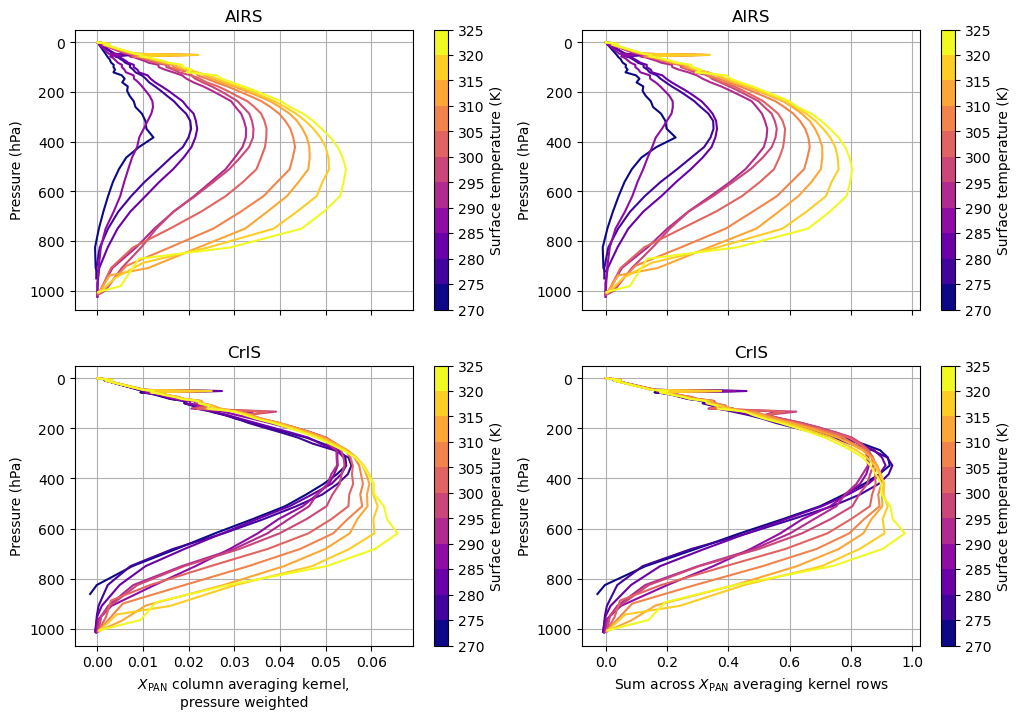

In [341]:
_, axs = plt.subplots(2, 2, figsize=(12,8), sharex='col')

ax = axs[0,0]
plot_median_aks_binned_by_value(
    airs_wcf_sep11_col_aks,
    binby=airs_filter_vars.surf_temp,
    bins=np.arange(270., 326., 5.),
    bin_label='Surface temperature (K)',
    filter_flag=airs_ak_flag,
    ax=ax
)
ax.set_xlabel('')
ax.set_title('AIRS')

ax = axs[1,0]
plot_median_aks_binned_by_value(
    cris_wcf_sep11_col_aks,
    binby=cris_filter_vars.surf_temp,
    bins=np.arange(270., 326., 5.),
    bin_label='Surface temperature (K)',
    filter_flag=(cris_filter_vars.quality_flag == 1) & (cris_filter_vars.land_flag == 1),
    ax=ax
)
ax.set_xlabel('$X_\\mathrm{PAN}$ column averaging kernel,\npressure weighted')
ax.set_title('CrIS')

ax = axs[0,1]
plot_median_aks_binned_by_value(
    airs_wcf_sep11_col_srak_aks,
    binby=airs_filter_vars.surf_temp,
    bins=np.arange(270., 326., 5.),
    bin_label='Surface temperature (K)',
    filter_flag=airs_ak_flag,
    ax=ax
)
ax.set_xlabel('')
ax.set_title('AIRS')

ax = axs[1,1]
plot_median_aks_binned_by_value(
    cris_wcf_sep11_col_srak_aks,
    binby=cris_filter_vars.surf_temp,
    bins=np.arange(270., 326., 5.),
    bin_label='Surface temperature (K)',
    filter_flag=(cris_filter_vars.quality_flag == 1) & (cris_filter_vars.land_flag == 1),
    ax=ax
)
ax.set_xlabel('Sum across $X_\\mathrm{PAN}$ averaging kernel rows')
ax.set_title('CrIS')

if SAVE_PLOTS:
    plt.savefig('img/airs_cris_column_aks.pdf', bbox_inches='tight')

In [169]:
def plot_dof_vs_xpan800(combined_file, colorbar=True, axs=None, hexbin_kws=dict(), hist_kws=dict()):
    with Dataset(combined_file) as ds:
        dofs = ds['DOFs'][:]
        xpan800 = aread.calc_xpan800(ds)

    xx = (dofs > -990) & (xpan800 > -990)
    dofs = dofs[xx]
    xpan800 = xpan800[xx]

    if axs is None:
        _, axs = plt.subplots(2, 2, figsize=(9,4), gridspec_kw={'width_ratios': [2,1], 'wspace': 0.1, 'height_ratios': [1,10]}, sharey='row')

    if colorbar:
        ax = axs[1,0]
        cax = axs[0,0]
    else:
        ax = axs[0]
        
    hexbin_kws.setdefault('mincnt', 1)
    hexbin_kws.setdefault('cmap', cmr.amber)
    hexbin_kws.setdefault('bins', 'log')
    h = ax.hexbin(xpan800, dofs, **hexbin_kws)
    ax.set_xlabel(r'XPAN800 (ppb)')
    ax.set_ylabel('Degrees of freedom (unitless)')
    ax.grid(True)
    
    if colorbar:
        plt.colorbar(h, cax=cax, label='# soundings', orientation='horizontal')
        if axs[0,1] is not None:
            axs[0,1].axis('off')

    if colorbar:
        ax = axs[1,1]
    else:
        ax = axs[1]
        
    hist_kws.setdefault('bins', 50)
    hist_kws.setdefault('edgecolor', 'black')
    hist_kws.setdefault('facecolor', 'lightgray') 
    ax.hist(dofs, orientation='horizontal', **hist_kws)
    ax.set_xlabel('# soundings')
    ax.grid(True)



def plot_airs_and_cris_dof_vs_xpan800(date, profile, vmax=1000, extent=[-2, 5, 0.0, 1.2]):
    fig = plt.figure(figsize=(9,8))
    gs = GridSpec(nrows=4, ncols=2, wspace=0.1, height_ratios=[10,10,0.5,1], width_ratios=[2,1])

    ax_cris_hex = fig.add_subplot(gs[0,0])
    ax_cris_hist = fig.add_subplot(gs[0,1], sharey=ax_cris_hex)
    ax_cris = [ax_cris_hex, ax_cris_hist]
    
    ax_airs_hex = fig.add_subplot(gs[1,0], sharex=ax_cris_hex)
    ax_airs_hist = fig.add_subplot(gs[1,1], sharex=ax_cris_hist, sharey=ax_airs_hex)
    cax = fig.add_subplot(gs[3,0])
    ax_airs = np.array([[cax, None], [ax_airs_hex, ax_airs_hist]])
    

    cris_file = f'data/validation/airs-runs/cris/{date}/combine/{profile}/Products_L2-PAN-0.nc'
    airs_file = f'data/validation/airs-runs/airs/{date}/combine/{profile}/Products_L2-PAN-0.nc'
    plot_dof_vs_xpan800(
        cris_file, colorbar=False, axs=ax_cris,
        hexbin_kws=dict(extent=extent, vmin=1, vmax=vmax), hist_kws=dict(bins=np.linspace(extent[2], extent[3]))
    )
    plot_dof_vs_xpan800(
        airs_file, colorbar=True, axs=ax_airs,
        hexbin_kws=dict(extent=extent, vmin=1, vmax=vmax), hist_kws=dict(bins=np.linspace(extent[2], extent[3]))
    )

    plt.setp(ax_cris_hex.get_xticklabels(), visible=False)
    plt.setp(ax_cris_hist.get_xticklabels(), visible=False)
    plt.setp(ax_cris_hist.get_yticklabels(), visible=False)
    ax_cris_hex.set_xlabel('')
    ax_cris_hex.set_ylabel('CrIS\nDegrees of freedom (unitless)')
    ax_cris_hist.set_xlabel('')
    ax_cris_hist.set_ylabel('')

    ax_airs_hex.set_ylabel('AIRS\nDegrees of freedom (unitless)')
    plt.setp(ax_airs_hist.get_yticklabels(), visible=False)
    ax_airs_hist.set_ylabel('')

    to_label = [ax_cris_hex, ax_cris_hist, ax_airs_hex, ax_airs_hist]
    labels = 'abcd'
    for ax, letter in zip(to_label, labels):
        ax.text(0.04, 0.96, f'({letter})', transform=ax.transAxes, weight='bold', va='top', backgroundcolor='white')

Calculating XPAN800 [######################################] 38236/38236
Calculating XPAN800 [######################################] 35934/35934


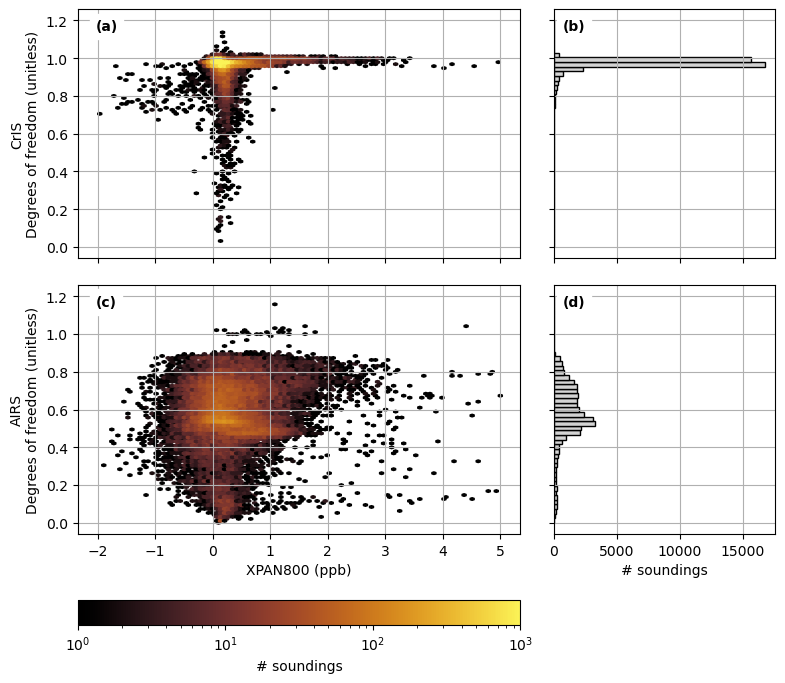

In [239]:
plot_airs_and_cris_dof_vs_xpan800('2020-09-11', 'West_Coast_Fires_Pacific')

if SAVE_PLOTS:
    plt.savefig('img/dofs-vs-xpan800.png', bbox_inches='tight')
    plt.savefig('img/dofs-vs-xpan800.pdf', bbox_inches='tight')